## 1. Підключення до бази даних в Google BiqQuery

In [ ]:
!pip install --upgrade google-cloud-bigquery

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
auth.authenticate_user()
from scipy.stats import ttest_ind, normaltest, mannwhitneyu
import statsmodels.api as sm
client = bigquery.Client(project="data-analytics-mate")

## 2. Створення запиту для отримання датасету

Датасет повинен містити такі поля:
*   дата замовлення
*   ідентифікатор сесії
*   котинент
*   країна
*   девайс
*   браузер
*   назва моделі пристрою
*   операційна система
*   мова браузера
*   інформація про джерело трафіку
*   канал трафіку
*   ідентифікатор зареєстрованого користувача
*   чи підтвердив користувач свій email
*   чи підписався користувач на розсилку
*   категорія товару
*   назва товару
*   ціна
*   короткий опис товару




In [ ]:
query = """
SELECT s.ga_session_id as session_id,
       s.date as date,
       sp.continent as continent,
       sp.country as country,
       sp.device as device,
       sp.browser as browser,
       sp.mobile_model_name as mobile_model_name,
       sp.operating_system as operating_system,
       sp.language as language,
       sp.channel as traffic_channel,
       sp.medium as traffic_source,
       acc.id as registered_account_id,
       acc.is_unsubscribed as is_unsubscribed,
       acc.is_verified as is_verified,
       p.category as category,
       p.name as product_name,
       p.price as product_price,
       p.short_description as product_description

FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` acc
ON acs.account_id = acc.id
LEFT JOIN `data-analytics-mate.DA.order` o
ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
ON o.item_id = p.item_id
"""

In [ ]:
query_job = client.query(query)
results = query_job.result()

In [ ]:
df = results.to_dataframe()
df.head()

,session_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_channel,traffic_source,registered_account_id,is_unsubscribed,is_verified,category,product_name,product_price,product_description
0,5760483956,2020-11-01,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,Paid Search,<Other>,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,7115337200,2020-11-01,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,Organic Search,organic,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,3978035233,2020-11-01,Europe,Norway,mobile,Chrome,<Other>,Web,zh,Direct,(none),<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,9648986282,2020-11-01,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,Direct,(none),<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,4393441533,2020-11-01,Asia,China,desktop,Chrome,Chrome,Windows,en-us,Direct,(none),<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## 3. Короткий опис отриманого датасету

### 3.1. Дослідження стовпчиків датасету

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   session_id             349545 non-null  Int64  
 1   date                   349545 non-null  dbdate 
 2   continent              349545 non-null  object 
 3   country                349545 non-null  object 
 4   device                 349545 non-null  object 
 5   browser                349545 non-null  object 
 6   mobile_model_name      349545 non-null  object 
 7   operating_system       349545 non-null  object 
 8   language               235279 non-null  object 
 9   traffic_channel        349545 non-null  object 
 10  traffic_source         349545 non-null  object 
 11  registered_account_id  27945 non-null   Int64  
 12  is_unsubscribed        27945 non-null   Int64  
 13  is_verified            27945 non-null   Int64  
 14  category               33538 non-nul

In [ ]:
print(f"Кількість стовпчикиів датасету: {df.shape[1]}\n")

def type_of_columns(df, data_types):
  for dtype in data_types:
    columns = df.select_dtypes(include = [dtype]).columns
    print(f"Кількість стовпчиків типу {dtype}: {len(columns)}")
    print(f"Список стовчпиків типу {dtype}: {list(columns)}\n")

data_types = ["number", "object", "dbdate"]
type_of_columns(df, data_types)

Кількість стовпчикиів датасету: 18

Кількість стовпчиків типу number: 5
Список стовчпиків типу number: ['session_id', 'registered_account_id', 'is_unsubscribed', 'is_verified', 'product_price']

Кількість стовпчиків типу object: 12
Список стовчпиків типу object: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_channel', 'traffic_source', 'category', 'product_name', 'product_description']

Кількість стовпчиків типу dbdate: 1
Список стовчпиків типу dbdate: ['date']



**ОТЖЕ:**   всього у датасеті 18 стовпців:

*  5 числових: 'session_id' (int64), 'registered_account_id' (int64), 'is_unsubscribed' (int64), 'is_verified' (int64), 'product_price' (float64)

*  12 категорій: 'continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_channel', 'traffic_source', 'category', 'product_name', 'product_description'

*  1 типу dbtime: 'date'

### 3.2. Описова статистика для числових даних

In [ ]:
df.describe()

,session_id,registered_account_id,is_unsubscribed,is_verified,product_price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.16944,0.71698,953.298679
std,2887450949.537772,13216.529465,0.375147,0.450474,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,0.0,1.0,445.000000
75%,7491286508.0,670414.0,0.0,1.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


**ОТЖЕ:**
*  session_id та registered_account_id є ідентифікаторами замовлень, отже описова статистика для них нічого не дає.  


*  is_unsubscribed та is_verified є булевими значеннями (0 та 1). Описова статистика демонструє високі значення is_verified (більше 0.7), що вказує на те, що більшість користувачів можуть бути верифікованими, is_unsubscribed показує менші значення, що означає, що більшість користувачів залишаються підписаними. Можна зробити висновок, що користувачі, які мають високу ймовірність верифікації, мають низький рівень відписки.


*  для product_price мінімальне значення - 3, найвище 9585. Медіанне значення становить 445, середнє 953.3, що майже в 2 рази більше ніж медіана, і це може свідчити про те, що в датасеті є аномальні значення. Стандартне відхилення у 1317 свідчить про високу варіативність та розкиданість даних.


### 3.3. Виявлення викидів та дублікатів

In [ ]:
def outliers_in_data(df):
  outliers = {}
  for col in df.select_dtypes(include = ["number"]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers_col = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers[col] = outliers_col
  return outliers

outliers = outliers_in_data(df)

for col, outlier_df in outliers.items():
    print(f"Аномалії в стовпці {col}:")

Аномалії в стовпці session_id:
Аномалії в стовпці registered_account_id:
Аномалії в стовпці is_unsubscribed:
Аномалії в стовпці is_verified:
Аномалії в стовпці product_price:


In [ ]:
duplicats = df.duplicated().sum()
duplicats

np.int64(0)

_За допомогою інтерквартильного діапазону, нижніх та верхніх меж зясували чи є вивиди у даних. Їх не виявлено. Дублікатів теж не вивлено_

### 3.4. Кількість унікальних сесій у кожному стовчпику


In [ ]:
for col in df.columns:
  unique_count = df[col].nunique()
  print(f"Частота пoяви унікальних значень у {col}:{unique_count}")

Частота пoяви унікальних значень у session_id:349545
Частота пoяви унікальних значень у date:92
Частота пoяви унікальних значень у continent:6
Частота пoяви унікальних значень у country:108
Частота пoяви унікальних значень у device:3
Частота пoяви унікальних значень у browser:6
Частота пoяви унікальних значень у mobile_model_name:10
Частота пoяви унікальних значень у operating_system:6
Частота пoяви унікальних значень у language:9
Частота пoяви унікальних значень у traffic_channel:5
Частота пoяви унікальних значень у traffic_source:6
Частота пoяви унікальних значень у registered_account_id:27945
Частота пoяви унікальних значень у is_unsubscribed:2
Частота пoяви унікальних значень у is_verified:2
Частота пoяви унікальних значень у category:14
Частота пoяви унікальних значень у product_name:550
Частота пoяви унікальних значень у product_price:829
Частота пoяви унікальних значень у product_description:1476


### 3.5. Який період часу розглядається (від… до…)?


In [ ]:
print(f"Дослідження проводилось від {df["date"].min()} до {df["date"].max()}")

Дослідження проводилось від 2020-11-01 до 2021-01-31


_Дослідження проводилось лише 3 місяці: листопад, грудень 2020 року та січень 2021 року._

### 3.6. Вияявлення пропущених значень

In [ ]:
missing_values = df.isnull().sum()
missing_cols = missing_values[missing_values > 0]
print("Стовпчики, які мають пропущенні значення:\n")
missing_cols

Стовпчики, які мають пропущенні значення:



,0
language,114266
registered_account_id,321600
is_unsubscribed,321600
is_verified,321600
category,316007
product_name,316007
product_price,316007
product_description,316007


In [ ]:
missing_percentage = df.isnull().mean() * 100
print(f"Відсоток пропущених значень:\n{missing_percentage}")

Відсоток пропущених значень:
session_id                0.000000
date                      0.000000
continent                 0.000000
country                   0.000000
device                    0.000000
browser                   0.000000
mobile_model_name         0.000000
operating_system          0.000000
language                 32.689925
traffic_channel           0.000000
traffic_source            0.000000
registered_account_id    92.005321
is_unsubscribed          92.005321
is_verified              92.005321
category                 90.405241
product_name             90.405241
product_price            90.405241
product_description      90.405241
dtype: float64


**ОТЖЕ:**
* Для _language_ 114,266 пропущених значень (або 32.68% від загальної кількості), це може означати, що частина користувачів не вказала свою мову або ці дані не були коректно заповнені.


* _registered_account_id, is_unsubscribed, is_verified_	мають однакову кількість пропущених значень - 321600 (або 92% від загальної кількості), це означає, що відсутня інформація про незареєстрованих користувачів


* _category, product_name, product_price, product_description_ ають однакову кількість пропущених значень - 316007 (або 90% від загальної кількості) м, це вказує на відсутність власне замовлень, яких 10% від загального


* Пропущених значень для замовлень менше ніж для registered_account_id, is_unsubscribed, is_verified, отже не всі зареєстровані користувачі зробили замовлення.

## 4. Візуалізації

### 4.1. На яких континентах (топ-3) та в яких країнах (топ-5) наша компанія має найбільші продажі? найбільшу кількість замовлень?


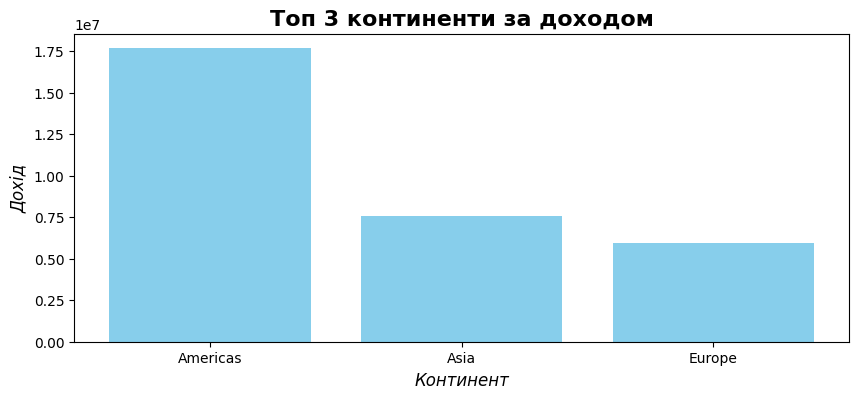

In [ ]:
top_3_continent_revenue = df.groupby("continent")["product_price"].sum().sort_values(ascending = False).head(3).reset_index()

plt.figure(figsize =(10, 4))
plt.bar(top_3_continent_revenue["continent"], top_3_continent_revenue["product_price"], color = "skyblue")
plt.title("Топ 3 континенти за доходом", fontsize = 16, fontweight = "bold")
plt.xlabel("Континент", fontsize = 12, fontstyle = "italic")
plt.ylabel("Дохід", fontsize = 12, fontstyle = "italic")
plt.show()

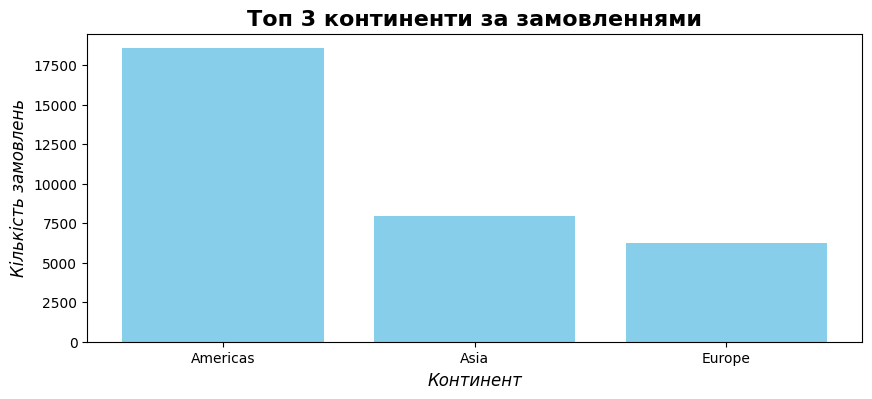

In [ ]:
top_3_continent_orders = df.groupby("continent")["product_name"].count().sort_values(ascending = False).head(3).reset_index()
plt.figure(figsize =(10, 4))
plt.bar(top_3_continent_orders["continent"], top_3_continent_orders["product_name"], color = "skyblue")
plt.title("Топ 3 континенти за замовленнями", fontsize = 16, fontweight = "bold")
plt.xlabel("Континент", fontsize = 12, fontstyle = "italic")
plt.ylabel("Кількість замовлень", fontsize = 12, fontstyle = "italic")
plt.show()

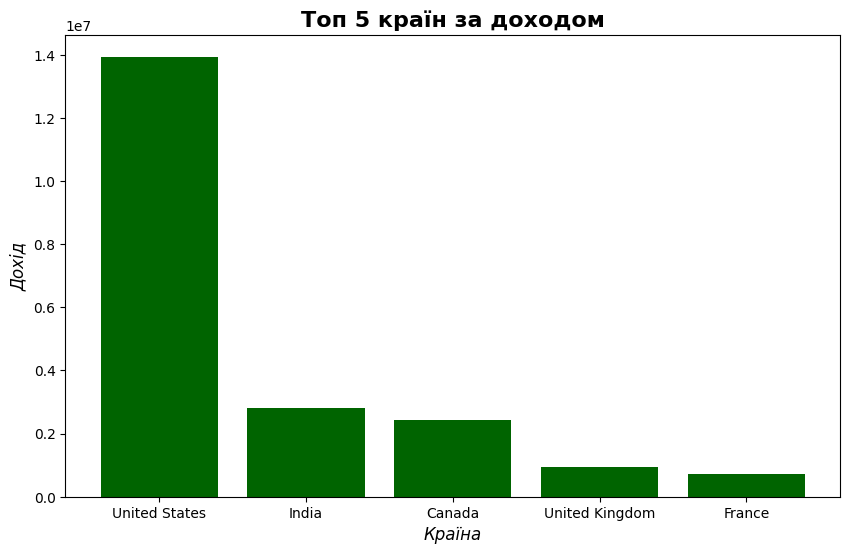

In [ ]:
top_5_countries_revenue = df.groupby("country")["product_price"].sum().sort_values(ascending =False).head().reset_index()
plt.figure(figsize =(10, 6))
plt.bar(top_5_countries_revenue["country"], top_5_countries_revenue["product_price"], color = "darkgreen")
plt.title("Топ 5 країн за доходом", fontsize = 16, fontweight = "bold")
plt.xlabel("Країна", fontsize = 12, fontstyle = "italic")
plt.ylabel("Дохід", fontsize = 12, fontstyle = "italic")
plt.show()

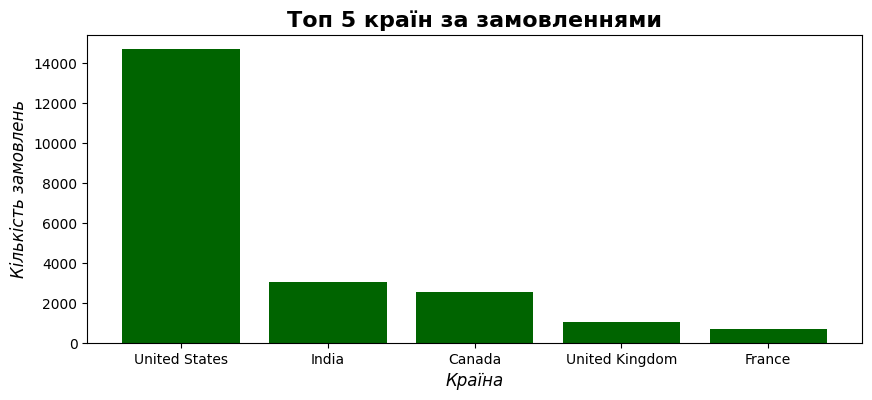

In [ ]:
top_5_countries_orders = df.groupby("country")["product_name"].count().sort_values(ascending = False).head().reset_index()
plt.figure(figsize =(10, 4))
plt.bar(top_5_countries_orders["country"], top_5_countries_orders["product_name"], color = "darkgreen")
plt.title("Топ 5 країн за замовленнями", fontsize = 16, fontweight = "bold")
plt.xlabel("Країна", fontsize = 12, fontstyle = "italic")
plt.ylabel("Кількість замовлень", fontsize = 12, fontstyle = "italic")
plt.show()

**ОТЖЕ:**
* Для континенту що по кількості продажам, що по кількості замовлень лідирує _Америки_, далі _Азія_ та дещо менше _Європа_
* Для країнам що по кількості продажам, що по кількості замовлень лідирують _США_, набагато менше _Індія_, далі _Канада, Велика Британія, Франція_

 ### 4.2. Знайти топ-10 категорій товарів за загальною сумою продажів

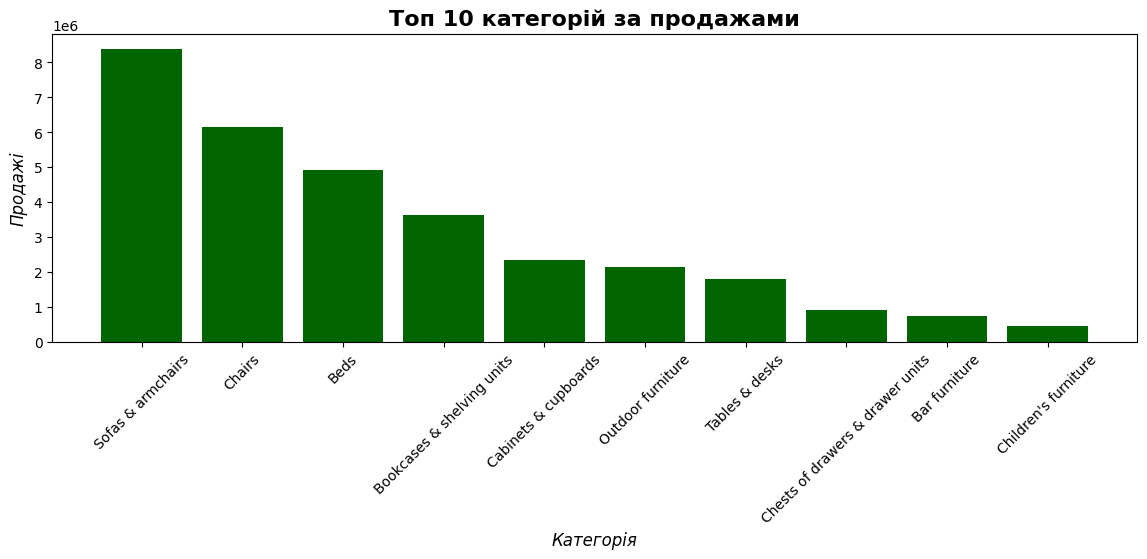

In [ ]:
top_10_cat_revenue = df.groupby("category")["product_price"].sum().sort_values(ascending = False).head(10).reset_index()
plt.figure(figsize =(14, 4))
plt.bar(top_10_cat_revenue["category"], top_10_cat_revenue["product_price"], color = "darkgreen")
plt.title("Топ 10 категорій за продажами", fontsize = 16, fontweight = "bold")
plt.xlabel("Категорія", fontsize = 12, fontstyle = "italic" )
plt.ylabel("Продажі", fontsize = 12, fontstyle = "italic")
plt.xticks(rotation=45)
plt.show()

**ОТЖЕ:**

За продажами найбільшими категоріями Sofas & armchairs, Chairs, Beds, найменшими є Childrens furniture, Bar furniture, Chests of drawers & drawer units. Найменше продажів дають вузькі категорії такі як дитячі меблі або барні меблі, в той час як найбільші категорії є більш універсальними і їх можуть частіше замовляти.

### 4.3. Знайти топ-10 категорій товарів у країні з найбільшими продажами, чи відрізняється ситуація від загальної?

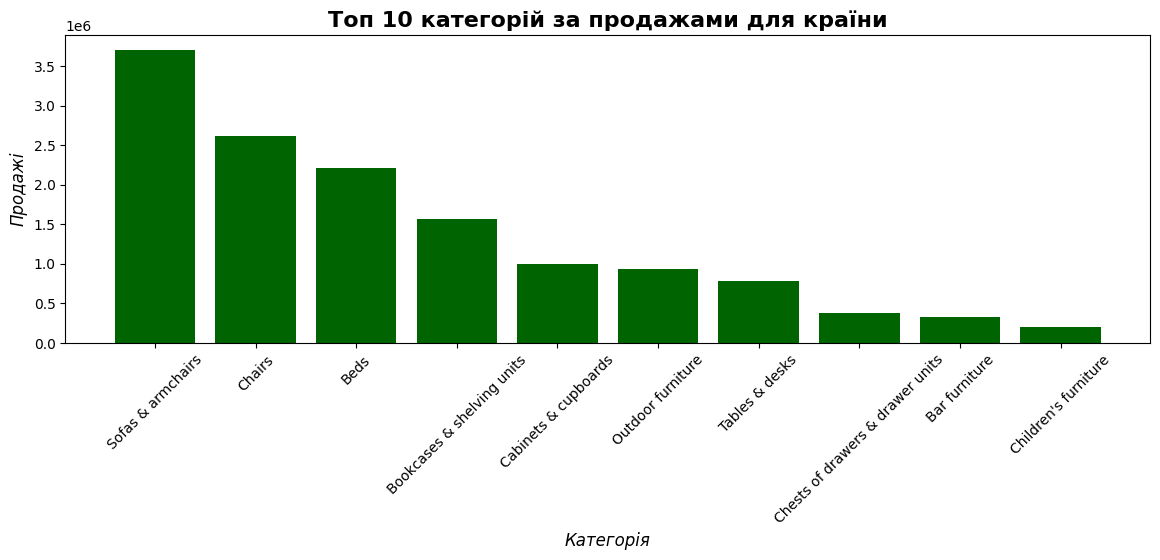

In [ ]:
country_by_revenue = df.groupby("country")["product_price"].sum().sort_values(ascending = False).index[0]
country_data = df[df["country"] == country_by_revenue]
cat_country_by_revenue = country_data.groupby("category")["product_price"].sum().sort_values(ascending = False).head(10).reset_index()
plt.figure(figsize =(14, 4))
plt.bar(cat_country_by_revenue["category"], cat_country_by_revenue["product_price"], color = "darkgreen")
plt.title("Топ 10 категорій за продажами для країни", fontsize = 16, fontweight = "bold")
plt.xlabel("Категорія", fontsize = 12, fontstyle = "italic" )
plt.ylabel("Продажі", fontsize = 12, fontstyle = "italic")
plt.xticks(rotation=45)
plt.show()

Загальні продажі для всіх категорій не відрізняються для топ-10 категорій товарів у країни з найбільшими продажами

### 4.4. Проаналізувати продажі у розрізі типів девайсів, операційних систем, браузера, мов, каналів трафіку (у % від загальних продажів)

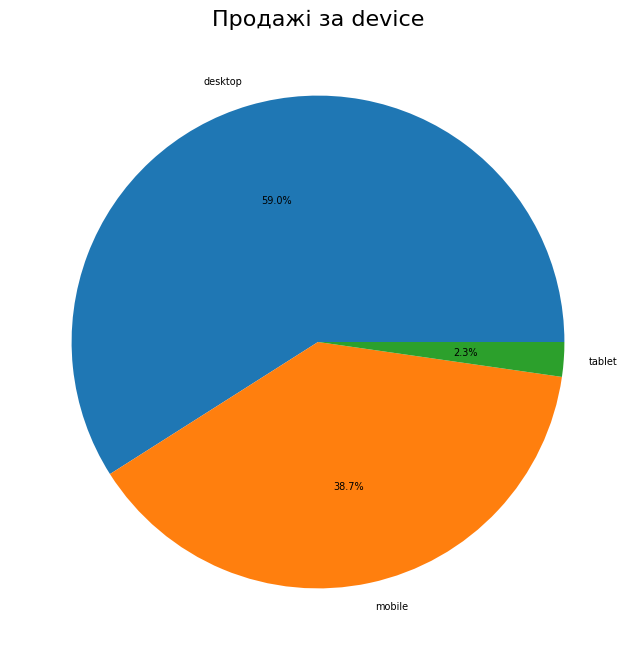

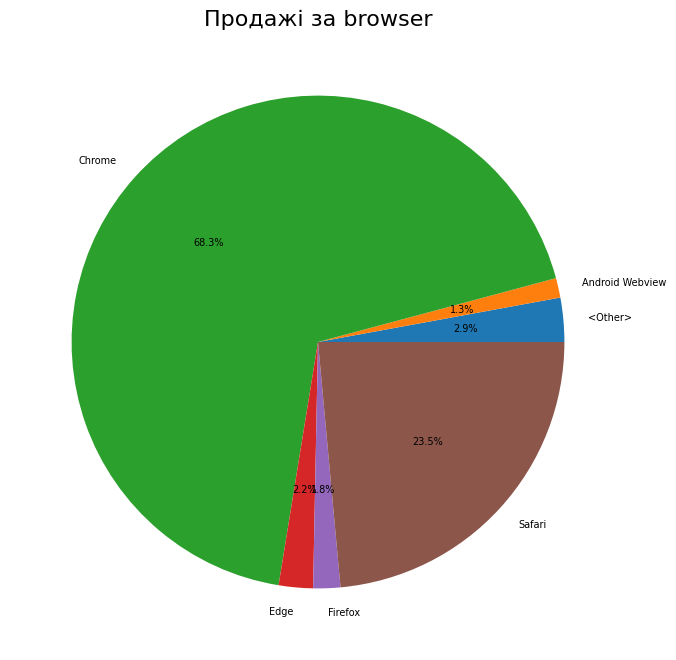

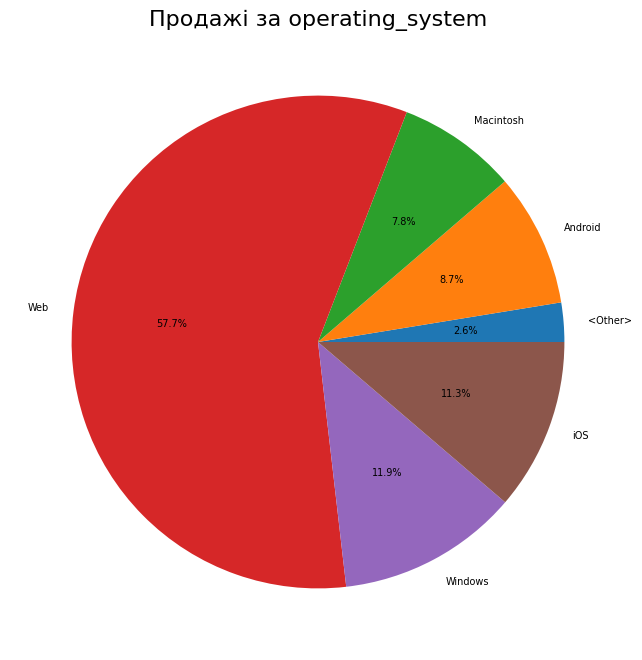

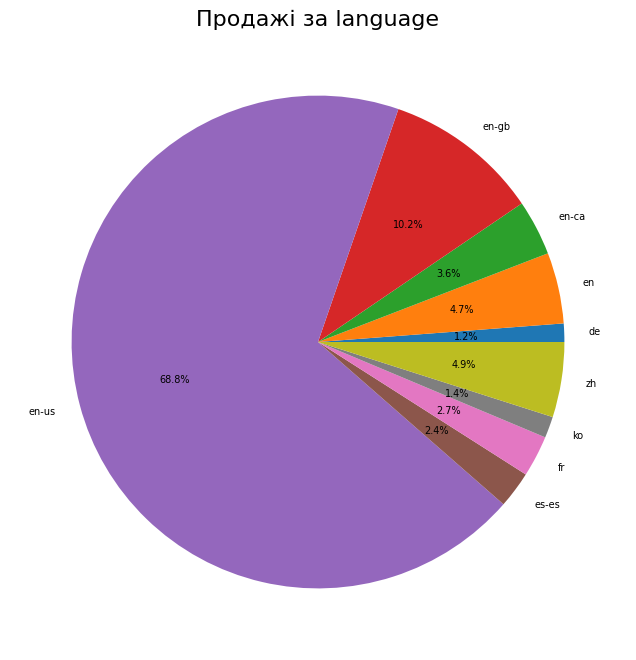

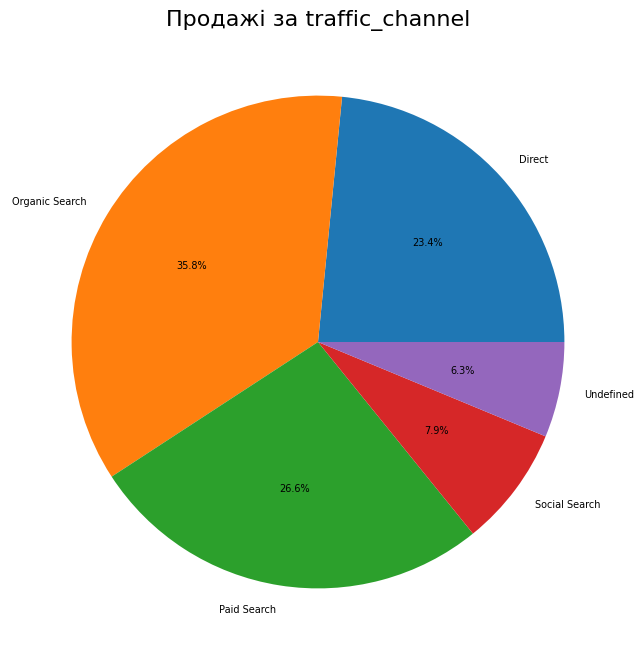

In [ ]:
categories = ["device", "browser", "operating_system", "language", "traffic_channel"]
for category in categories:
  category_sales = df.groupby(category)["product_price"].sum().reset_index()
  plt.figure(figsize=(8, 8))
  plt.pie(category_sales["product_price"], labels = category_sales[category], autopct = "%1.1f%%",  textprops={'fontsize': 7})
  plt.title(f"Продажі за {category}", fontsize=16)
plt.show()

**ОТЖЕ:**
*  _За девайсами_: більшість desktop(59%), далі mobile(38.7%), tablet(2.3%)
*  _За браузером_: більшість Chrome(68.3%), друга за більшістю(23.5%), далі Other(2.9%), Edge(2.2%), Firefox(1.8%), Android Webview(1.3%)
*  _За операційною системою_: більшість займає Web(57.7%), далі Windows(11.9%), iOS(11.3%), Android(8.7%), Macintosh(7.8%), Other(2.6%)
*  _За мовою_: бальшість займає американська англійська (en-us - 68.8%), далі британська англійська (en-gb - 10.2%), китайська (zh - 4.9%), звичайна англійська (en - 4.7%), канадська англійська (en-ca - 3.6%), французька (fr - 2.7%), іспанська (es-es - 2.4%), корейська (ko - 1.4%), німецька (de - 1.2%)
*  _За каналами трафіку_: найбільше має Organic Search (35.8%), Paid Search (26.6%), Direct (23.4%), Social Search (7.9%), Underfined (6.3%)

### 4.5. Який відсоток зареєстрованих користувачів підтвердив свою електронну адресу?


In [ ]:
registered_ac = df["registered_account_id"].nunique()
percentage_of_verified = df[df["is_verified"] == 1].shape[0]/registered_ac * 100
print(f"Відсоток підтверджених користувачів: {round(percentage_of_verified, 2)}%")

Відсоток підтверджених користувачів: 71.7%


_is_verified_ (чи підтверджений акаунт): **1** (підтверджений), **0** (непідтверджений)

Кількість підтверджених користувачів становить 71.7%


### 4.6. Який відсоток зареєстрованих користувачів відписався від розсилки?

In [ ]:
percentage_of_unsubscribed = df[df["is_unsubscribed"] == 1].shape[0]/registered_ac * 100
print(f"Відсоток зарєєстрованих користувачів, що відписались від розсилки: {round(percentage_of_unsubscribed, 2)}%")

Відсоток зарєєстрованих користувачів, що відписались від розсилки: 16.94%


_is_unsubscribed_ (відписаний від росилки): **0** (невідписаний), **1** (відписаний)

Відсоток відписаних від розсилок серед зареєстрвоаних становить 16.94%

### 4.7. Чи відрізняється поведінка (у плані продажів) тих, хто відписався від розсилки та тих, хто досі підписаний?


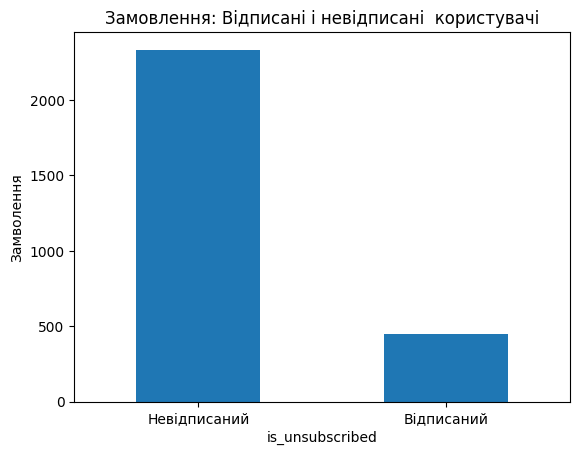

In [ ]:
orders_by_subscription = df.groupby("is_unsubscribed")["product_name"].count().sort_values(ascending = False)
orders_by_subscription.plot(kind="bar", title="Замовлення: Відписані і невідписані  користувачі")
plt.ylabel("Замволення")
plt.xticks([0, 1], ["Невідписаний", "Відписаний"], rotation = 0)
plt.show()

Користувачі, що підписані на розсилку набагато частіше роблять замовлення. Варто зазначити, що дана візуалізація відображає поведінку лише для зареєстрованих користувачів, оскільки тільки вони мають можливість підписатись на розсилку.

Якщо враховувати те, що незареєстровані користувачі теж не отримують розсилки, то візуалізація буде виглядати іншим чином:

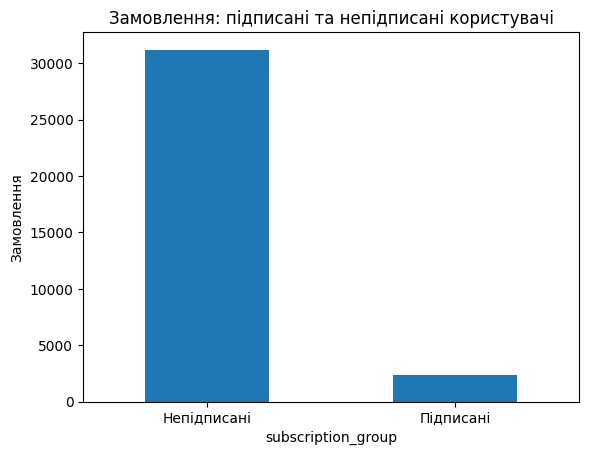

In [ ]:
# 0 — підписані на розсилку
# 1 та NaN — не підписані на розсилку

df["subscription_group"] = df["is_unsubscribed"].apply(lambda x: "Непідписані" if pd.isna(x) or x == 1 else "Підписані")
orders_by_subscription = df.groupby("subscription_group")["product_name"].count().sort_values(ascending=False)

orders_by_subscription.plot(kind="bar", title="Замовлення: підписані та непідписані користувачі")
plt.ylabel("Замовлення")
plt.xticks(rotation=0)
plt.show()

В такому випадку непідписані роблять більше замовлень

### 4.8. Чи відрізняється поведінка (у плані продажів) тих, хто зареєстрований та тих, хто ні?

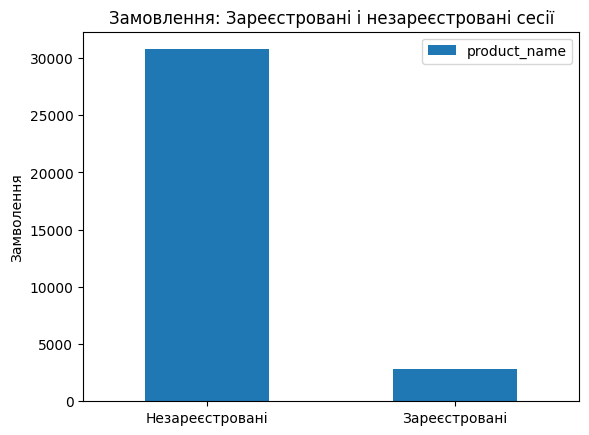

In [ ]:
df["is_registered"] = df["registered_account_id"].notnull()
orders_by_registration = df.groupby("is_registered")["product_name"].count().sort_values(ascending = False).reset_index()
orders_by_registration.plot(kind="bar", title="Замовлення: Зареєстровані і незареєстровані сесії")
plt.ylabel("Замволення")
plt.xticks([0, 1], ["Незареєстровані", "Зареєстровані"], rotation = 0)
plt.show()

Незареєстровані користувачі частіше роблять замовлення ніж зареєстровані приблизно в 7 разів

### 4.9. В яких країнах найбільше зареєстрованих користувачів?

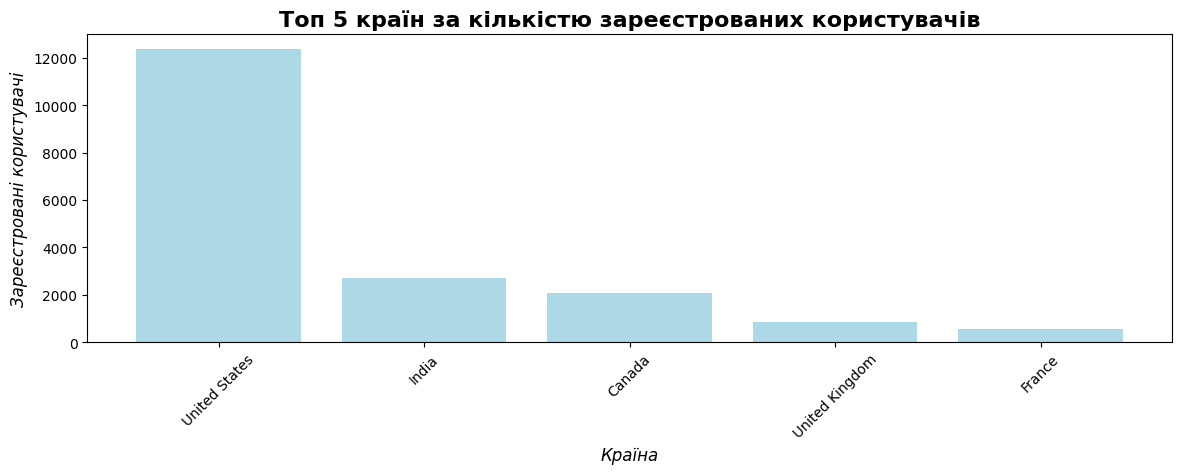

In [ ]:
countries_by_registrations = df.groupby("country")["registered_account_id"].nunique().sort_values(ascending = False).head(5).reset_index()
plt.figure(figsize =(14, 4))
plt.bar(countries_by_registrations["country"], countries_by_registrations["registered_account_id"], color = "lightblue")
plt.title("Топ 5 країн за кількістю зареєстрованих користувачів", fontsize = 16, fontweight = "bold")
plt.xlabel("Країна", fontsize = 12, fontstyle = "italic" )
plt.ylabel("Зареєстровані користувачі", fontsize = 12, fontstyle = "italic")
plt.xticks(rotation=45)
plt.show()

Найбільше зареєстрвоних користувачів в США, Індія, Канада, Велика Британія, Франція. Ці ж самі країни роблять найбільше замовлень відповідно до попередніх візуалізацій

### 4.10. Зясувати як топ-6 мов використовуються в топ-5 країнах по продажам.

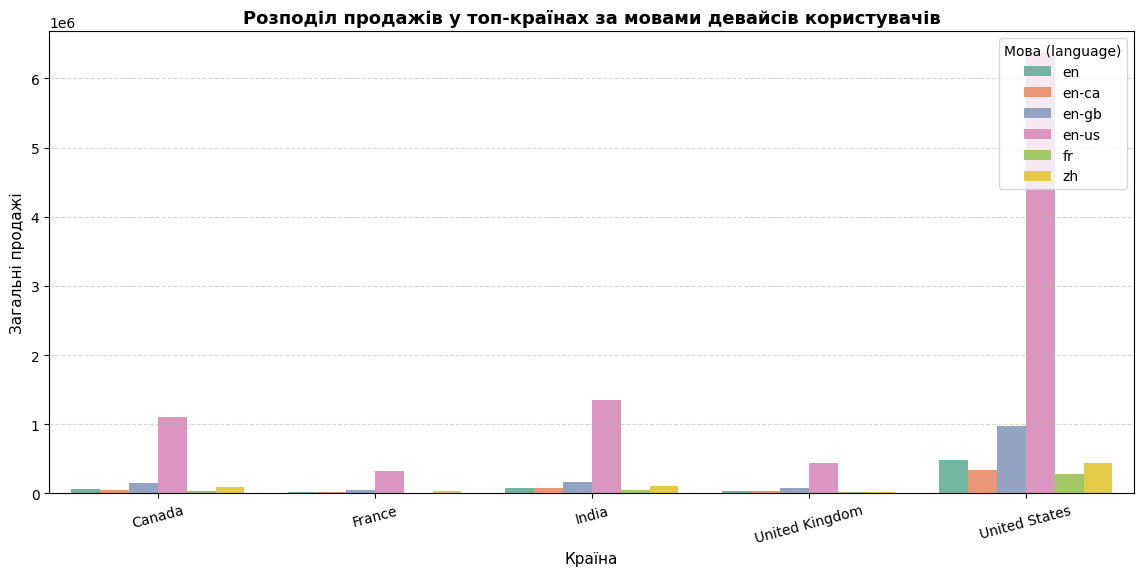

In [ ]:
top_5_countries = df.groupby("country")["product_price"].sum().nlargest(5).index
top_6_languages = df.groupby("language")["product_price"].sum().nlargest(6).index

df_filtered_geo = df[(df["country"].isin(top_5_countries)) & (df["language"].isin(top_6_languages))]
geo_data = df_filtered_geo.groupby(["country", "language"])["product_price"].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=geo_data, x="country", y="product_price", hue="language", palette="Set2")

plt.title("Розподіл продажів у топ-країнах за мовами девайсів користувачів", fontsize=13, fontweight='bold')
plt.xlabel("Країна", fontsize=11)
plt.ylabel("Загальні продажі", fontsize=11)
plt.legend(title="Мова (language)", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.show()

**Отже:**
*  Явно домінує en-us, при чому у всіх країнах. Продажі з девайсів із налаштуванням en-us у США перевищують 6 мільйонів доларів, en-us є лідером в усіх інших топ-країнах: у Канаді, Індії, Великій Британії та навіть у Франції (при чому навіть більше ніж французька)
*  У США помітна значна частка локалі en-gb (британська англійська — синій стовпчик), яка приносить близько 1 мільйона доларів. Це свідчить про наявність великої кількості експатів або людей, що використовують британські версії систем/браузерів.
*  У Канаді продажі з девайсів en-ca (канадська англійська) майже непомітні на тлі en-us, і тому, можливо немає сенсу адаптовувати продукт під канадську англійську, оскільки нею мало користуються і вона схожа до американської англійської.
*  Зелений стовпчик zh (китайська мова) присутній у невеликій, але стабільній кількості в США, Канаді та Індії.

Багато користувачів використовуються en-us і можуть не змінювати стандартні налаштування мови або використовують американську англійську як міжнародну, навіть в країнах де вона не є основною для спілкування.

## 5.Аналіз динаміки продажів

### 5.1. Знайти загальні продажі за кожну дату, створити візуалізацію загальної динаміки продажів


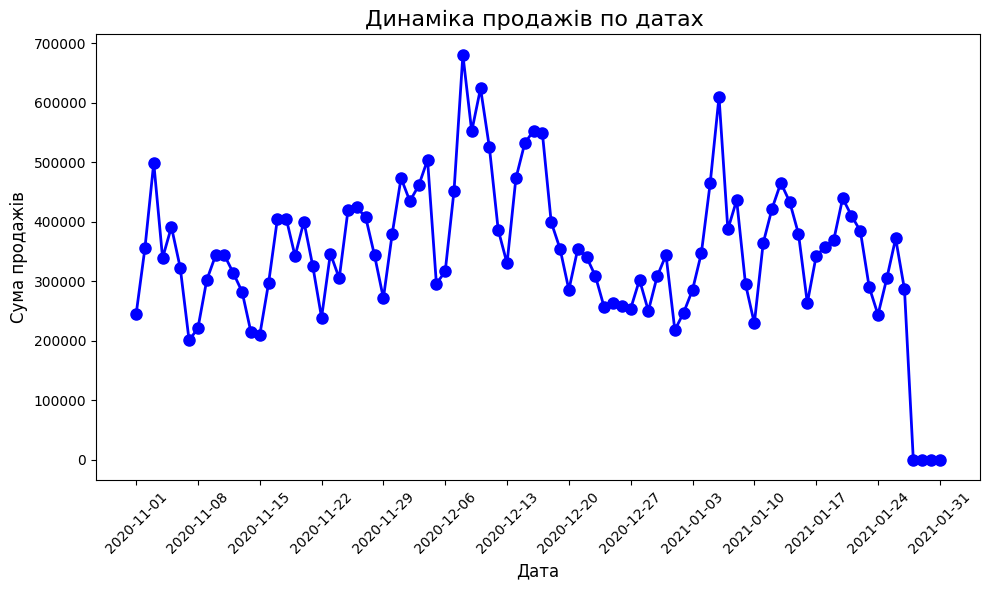

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df_grouped = df.groupby("date")["product_price"].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(df_grouped["date"], df_grouped["product_price"], color="blue", marker="o", markersize=8, linestyle="-", linewidth=2)
plt.xticks(df_grouped["date"][::7], df_grouped["date"].dt.strftime("%Y-%m-%d")[::7], rotation = 45)
plt.title("Динаміка продажів по датах ", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума продажів", fontsize=12)
plt.tight_layout()
plt.show()

**Маємо наступні висновки:**

1.  В листопаді продажі відносно стабільні, коливаються, але не має настільки різких падінь. У грудні продажі нестабільні, на початку грудня високі продажі, а після середини грудня продажі почали падати, що може бути зумовлено завчасною підготовкою до новорічних/різдвяних свят
2.  Найбільші продажі маємо на початку грудня близько 680000 певної валюти, найменше на початку листопада (близька 200000 валюти) або останній тиждень січня. Також є значне підвищення продажів на почтаку січня (близько 600000 валюти).
3.   За останній тиждень січня спостерігаємо значне падіння продажів, це може бути спричинене відсутністю продажів або ж відсутністю записів/завершення певного статистичного дослідження


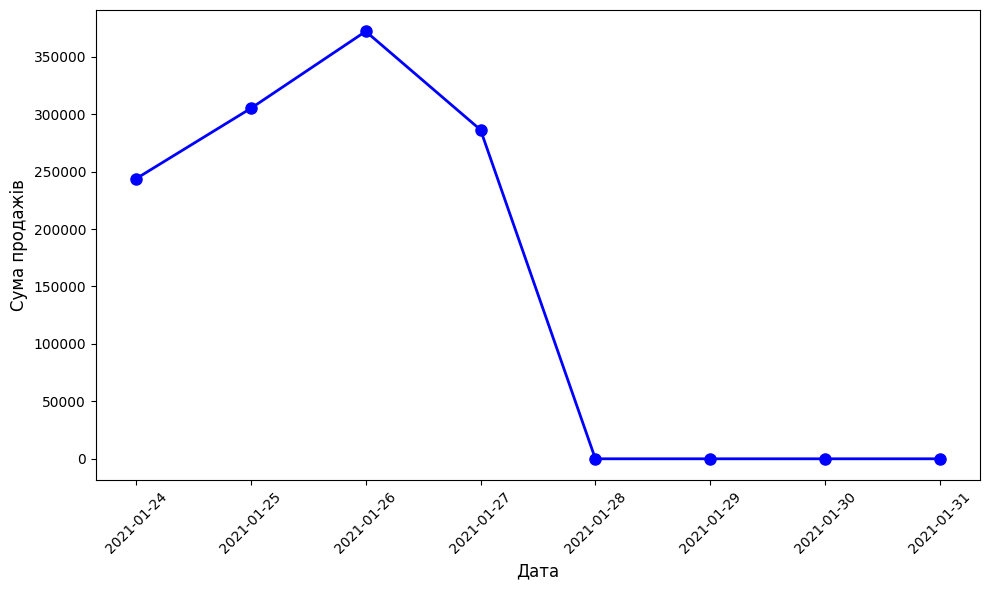

In [ ]:
start_date = "2021-01-24"
end_date = "2021-01-31"
filtered_df = df_grouped[(df_grouped["date"] >= start_date)&(df_grouped["date"] <= end_date)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df["date"], filtered_df["product_price"], color="blue", marker="o", markersize=8, linestyle="-", linewidth=2)
plt.xticks(rotation=45)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Сума продажів", fontsize=12)
plt.tight_layout()
plt.show()

Можна сказати, що зниження в останній тиждень січня скоріше за все спричинений відсутністю даних в останні 4 дні.

4.  На шкалу абсцис нанесено зміну продажів кожного тижня. Помітно, що присутні коливання в межах тижня, це може бути повязано з меншими продажами в певний день тижня, це додатково можна перевірити

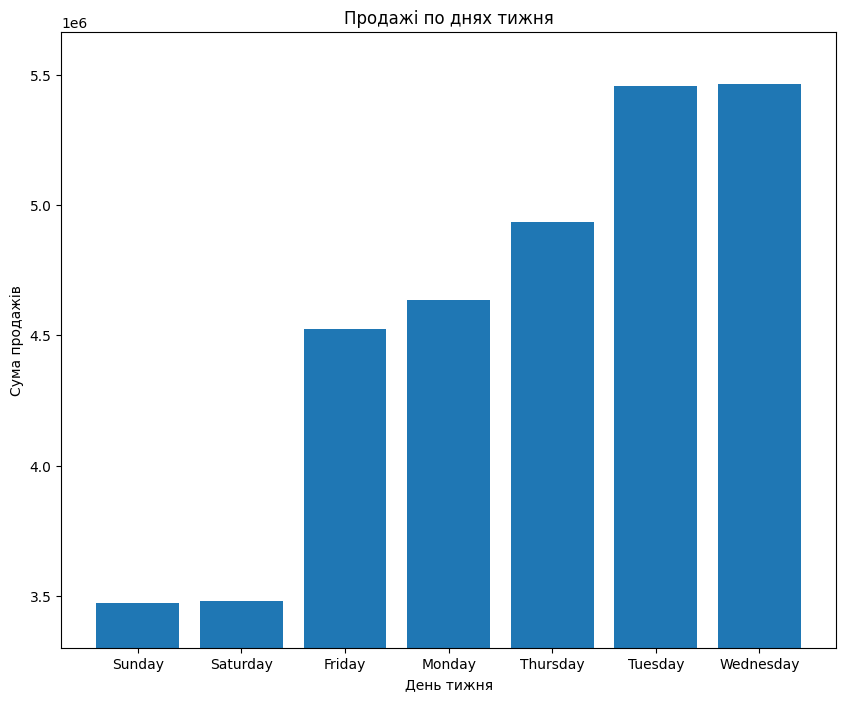

In [ ]:
df["day_name"] = df['date'].dt.day_name()
df_grouped_day_week = df.groupby("day_name")["product_price"].sum().sort_values().reset_index()
plt.figure(figsize = (10, 8))
plt.bar(df_grouped_day_week["day_name"], df_grouped_day_week["product_price"])
plt.title("Продажі по днях тижня")
plt.xlabel("День тижня")
plt.ylabel("Сума продажів")
plt.ylim(3300000, df_grouped_day_week["product_price"].max() + 200000)
plt.show()

Отже, найбільші продажі в середу та вівторок, найменші в неділю та суботу. Таким чином, в середньому збільшуються продажі до середи, в четверг починають знижуватись до неділі і в понеділок знову підвищуються

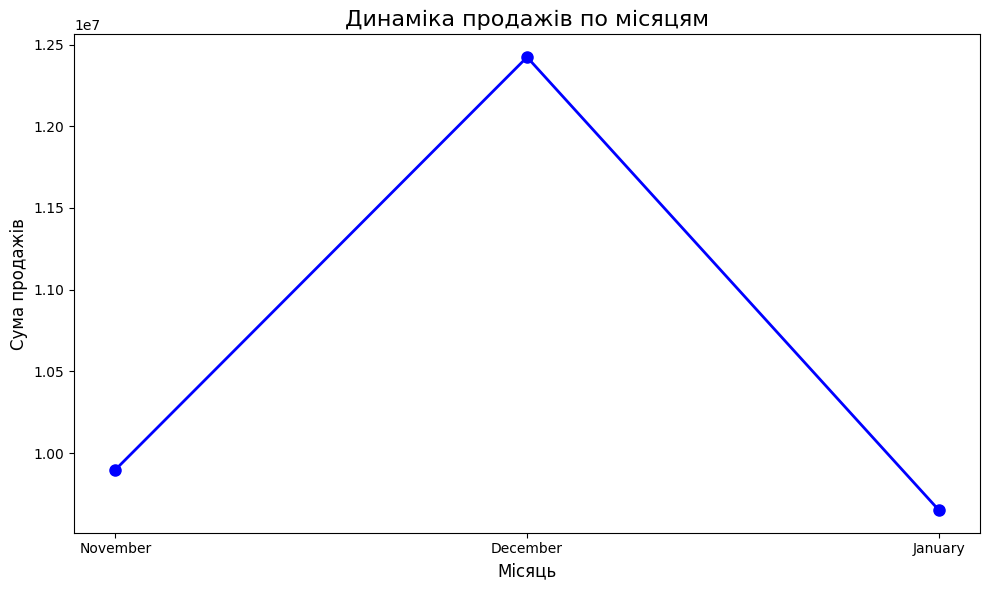

In [ ]:
df["year_month"] = df["date"].dt.to_period("M")
df_grouped = df.groupby("year_month")["product_price"].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(df_grouped["year_month"].astype(str), df_grouped["product_price"], color="blue", marker="o", markersize=8, linestyle="-", linewidth=2)
plt.title("Динаміка продажів по місяцям", fontsize=16)
plt.xlabel("Місяць", fontsize=12)
plt.ylabel("Сума продажів", fontsize=12)
plt.xticks(["2020-11", "2020-12", "2021-01"], ["November", "December", "January"], rotation = 0)
plt.tight_layout()
plt.show()

Загальна динаміка продажів за місяцями показує, що найвищий обсяг продажів був у грудні. У листопаді продажі були нижчими, а в січні спостерігається спад.

Це може свідчити про сезонність у продажах: у грудні попит зростає, ймовірно, через передсвятковий період і відповідні акції. У січні продажі знижуються, що може бути пов’язано зі спадом активності після святкового періоду.

### 5.2. Проаналізувати динаміку продажів в Америці, Азії та Європі

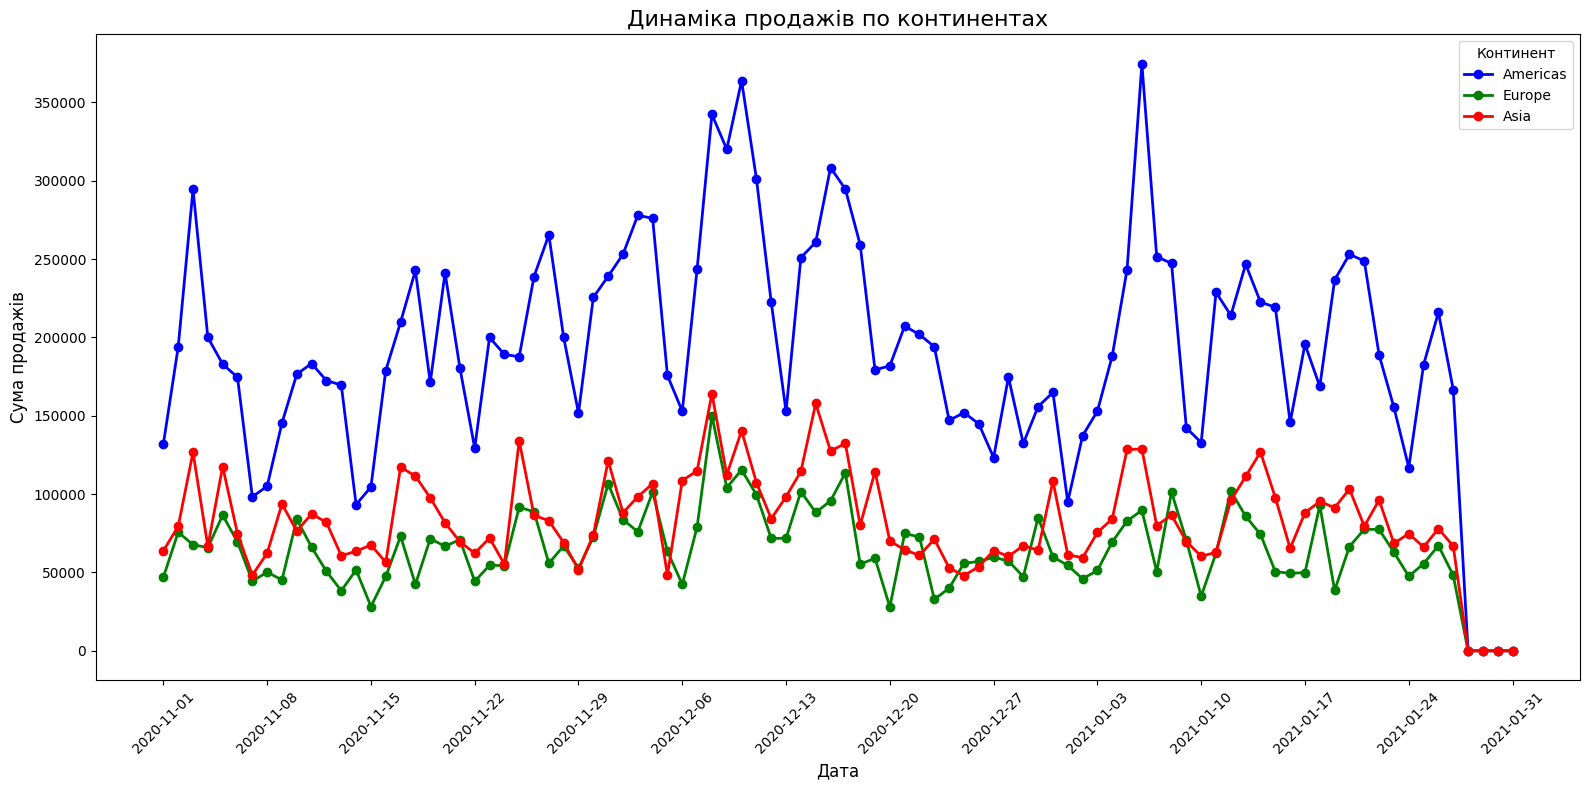

In [ ]:
sales_by_continent = df.groupby(["continent", "date"])["product_price"].sum().reset_index()
continents = ["Americas", "Europe", "Asia"]
colors = ["blue", "green", "red"]

plt.figure(figsize=(16, 8))
for i, continent in enumerate(continents):
  continent_data = sales_by_continent[sales_by_continent["continent"] == continent]
  plt.plot(continent_data["date"], continent_data["product_price"],  label = continent, color = colors[i], marker = "o", linewidth = 2)

plt.title("Динаміка продажів по континентах", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.xticks(continent_data["date"][::14], rotation = 45)
plt.ylabel("Сума продажів", fontsize=12)
plt.legend(title="Континент")
plt.tight_layout()
plt.show()

**Отже:**
*  Найбільше продажів на континенті Americas від близько 80 тис. до 400 тис., з великою кількістю пікових значень та різких коливань
*  Europe та Asia мають дещо схожий графік, обидва знаходяться в межах близько 30тис. до 150 тис., що значнг менше ніж в Americas, так само присутні пікові значення та значні коливання
*  Спад та зростання продажів на кожному з розглянутих континентів спостерігається в майже одних і тих самих точках, що може бути спричинено сезонністю, скоріше за все тижневою сезонністю, а також однаковими різдвяними святами. Або ж якщо компанія запускає масштабну глобальну рекламу, знижки тощо, реакція покупців відбувається одночасно на всіх ринках.

### 5.3. Проаналізувати динаміку продажів у розрізі каналів трафіку


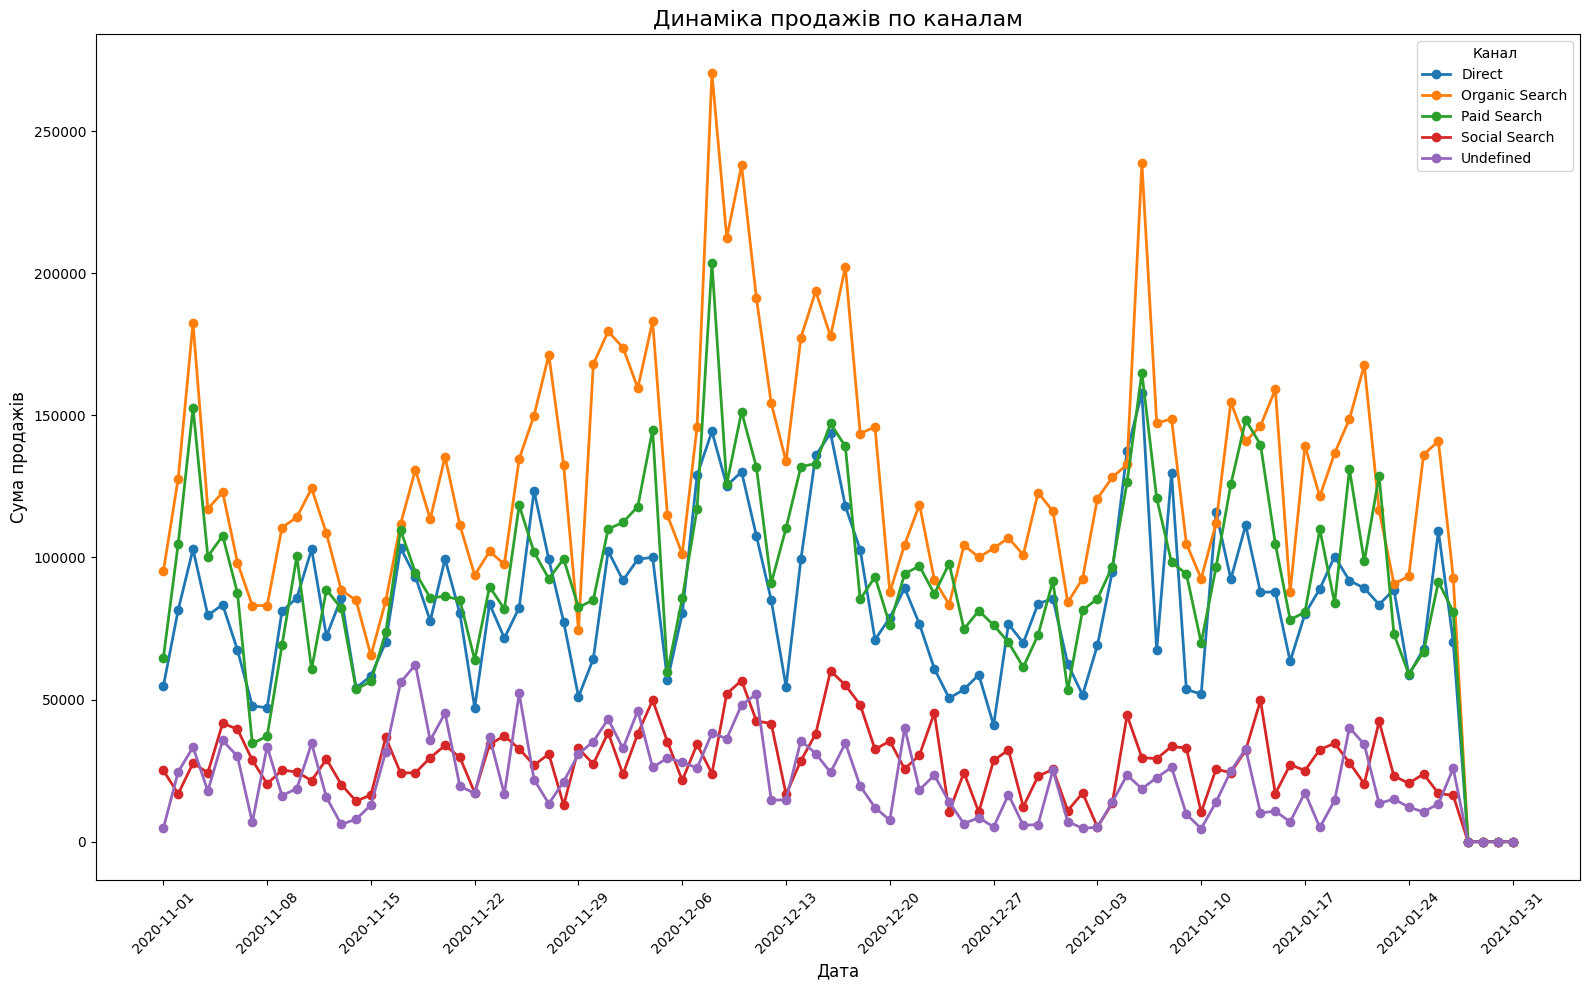

In [ ]:
sales_by_channel = df.groupby(["traffic_channel", "date"])["product_price"].sum().reset_index()
channels= sales_by_channel["traffic_channel"].unique()

plt.figure(figsize=(16, 10))
for  channel in channels:
  channel_data = sales_by_channel[sales_by_channel["traffic_channel"] == channel]
  plt.plot(channel_data["date"], channel_data["product_price"],  label = channel,  marker = "o", linewidth = 2)

plt.title("Динаміка продажів по каналам", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.xticks(continent_data["date"][::7], rotation = 45)
plt.ylabel("Сума продажів", fontsize=12)
plt.legend(title="Канал")
plt.tight_layout()
plt.show()

**Отже:**
*  Домінує Organic Search і є головним джерелом продажів.
*  Існує сильна залежність між Paid Search та Organic Search, графіки рухаються майже синхронно. Це означає, що коли люди починають активно шукати продукт в інтернеті самостійно (органіка), обсяги платних оголошень ропорційно зростають
* Direct тримається на відносно високому рівні при цьому таких різких коливань як у Paid Search та Organic Search, оскільки це лояльна аудиторія, яка знає бренд і повертається безпосередньо.
*  Social Search (соціальні мережі) та Undefined (невизначені джерела) приносять найменше грошей. Вони слабо реагують навіть на загальні ринкові зростання (наприклад, на початку/середину грудня), і залишаються стабільно нижче



### 5.4. Проаналізувати динаміку продажів у розрізі типів девайсів, відображай різні девайси різними кольорами

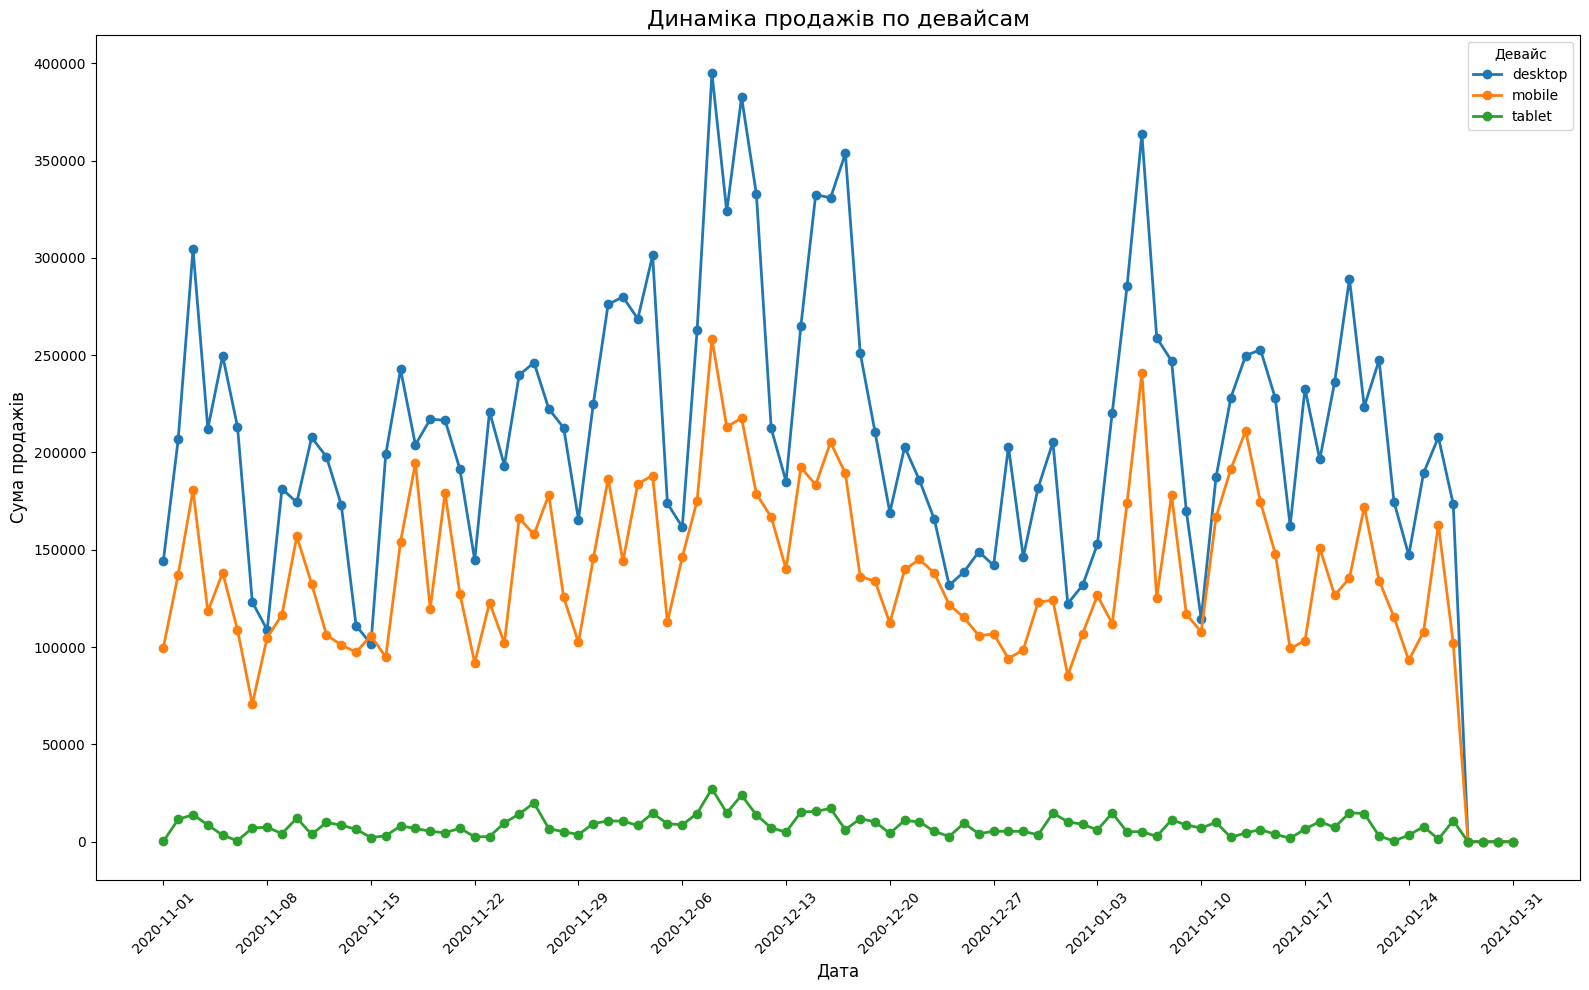

In [ ]:
sales_by_device = df.groupby(["device", "date"])["product_price"].sum().reset_index()
devices = sales_by_device["device"].unique()

plt.figure(figsize=(16, 10))
for device in devices:
  device_data = sales_by_device[sales_by_device["device"] == device]
  plt.plot(device_data["date"], device_data["product_price"],  label = device,  marker = "o", linewidth = 2)

plt.title("Динаміка продажів по девайсам", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.xticks(continent_data["date"][::7], rotation = 45)
plt.ylabel("Сума продажів", fontsize=12)
plt.legend(title="Девайс")
plt.tight_layout()
plt.show()

**Отже:**

*  Найбільше продажів дає desktop від близько 100тис.  до 400тис., потім mobile від близько 60тис. до 250тис., і дуже мало tablet з максимум в близько 25тис.
*  Попри глобальний тренд на мобільний трафік, клієнти все ще віддають перевагу десктопній версії для фінальної оплати товарів, можливо, десктопна версія сайту є значно зручнішою для оформлення замовлення.
*  Оптимізацією під планшети можна знехтувати на користь покращення мобільної та комп'ютерної версій сайту.

## 6. Зведені таблиці

### 6.1. Cтворити зведену таблицю, яка показує кількість сесій у розрізі каналів трафіку та типів девайсів (якщо значення якогось поля невідоме, не враховувати)


In [ ]:
pivot_table = pd.pivot_table(df, values = "session_id", index = "traffic_channel", columns = "device", aggfunc = "count", fill_value = 0)
pivot_table

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


### 6.2. Створити зведену таблицю, яка показує загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)

In [ ]:
grouped_data = df.groupby(["category", "country"])["product_price"].sum().reset_index()
top_10_cat = df.groupby("category")["product_price"].sum().sort_values(ascending = False).head(10).index
top_5_country = df.groupby("country")["product_price"].sum().sort_values(ascending = False).head(5).index

filtered_data = grouped_data[grouped_data["category"].isin(top_10_cat) & grouped_data["country"].isin(top_5_country)]
pivot_table = pd.pivot_table(filtered_data, values = "product_price", index = "category", columns = "country", aggfunc = "sum", fill_value = 0)
pivot_table

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


### 6.3. Створити зведену таблицю, яка показує продажі по місяцям у топ-5 країнах

In [ ]:
df["month"] = df["date"].dt.strftime("%B")
grouped_data = df.groupby(["country", "month"])["product_price"].sum().reset_index()
top_5_country = df.groupby("country")["product_price"].sum().sort_values(ascending = False).head(5).index
filtered_data = grouped_data[grouped_data["country"].isin(top_5_country)]
pivot_table = pd.pivot_table(filtered_data, values="product_price", index="month", columns="country", aggfunc="sum", fill_value=0)
pivot_table

country,Canada,France,India,United Kingdom,United States
month,,,,,
December,982674.4,288567.9,1068745.6,356120.5,5386580.8
January,713943.9,194139.5,867120.6,295387.4,4266095.8
November,741302.7,227985.4,873895.8,286810.0,4290877.3


## 7. Статистичний аналіз взаємозв’язків

### 7.1. Знайти кількість сесій та загальні продажі за кожну дату. Створити візуалізацію, щоб побачити взаємозв’язок між цими метриками. Чи корелюють ці показники? Знайти відповідний коефіцієнт кореляції та проаналізувати його статистичну значущість.


_Групування по кількості сесії та загальним продажам за кожну дату_

In [ ]:
from scipy.stats import normaltest, pearsonr, kendalltau, spearmanr
df_grouped = df.groupby(df["date"].dt.date).agg(sessions=("session_id", "nunique"),total_sales=("product_price", "sum")).reset_index()

_Перевірка на нормалість_

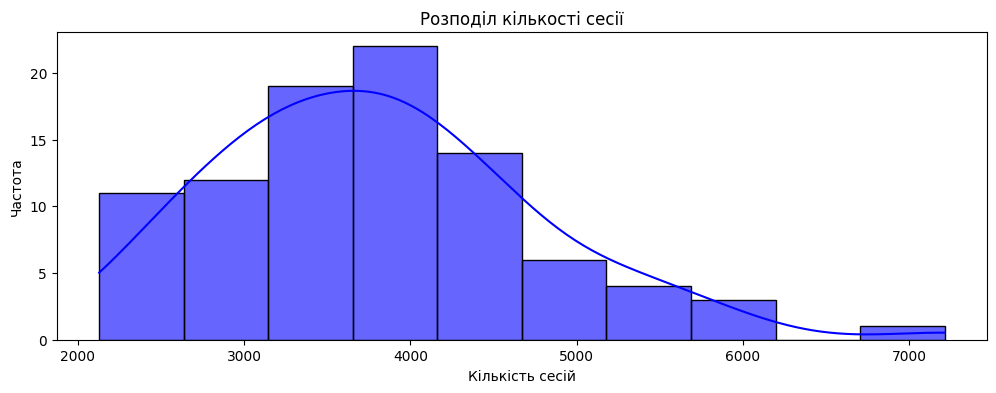

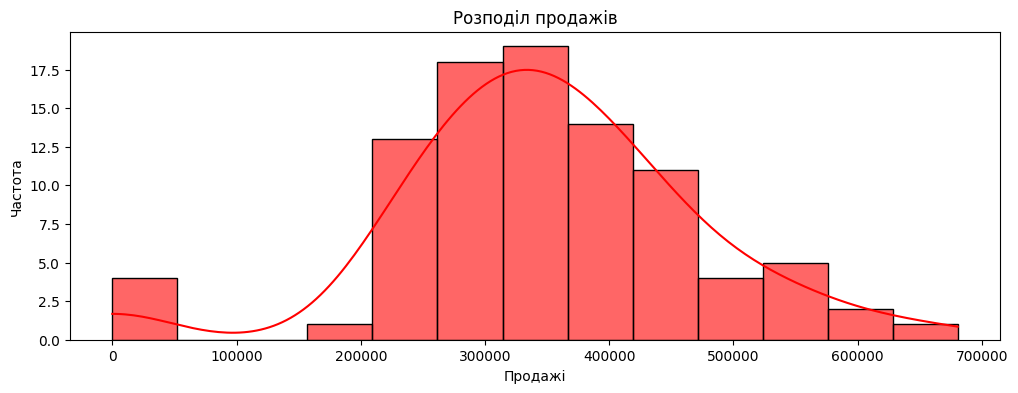

In [ ]:
plt.figure(figsize=(12, 4))
sns.histplot(df_grouped["sessions"], kde=True, color="blue", alpha=0.6)
plt.title("Розподіл кількості сесії")
plt.xlabel("Кількість сесій")
plt.ylabel("Частота")
plt.figure(figsize=(12, 4))
sns.histplot(df_grouped["total_sales"], kde=True, color="red", alpha=0.6)
plt.title("Розподіл продажів")
plt.xlabel("Продажі")
plt.ylabel("Частота")
plt.show()

In [ ]:
stat_session, p_value_session = normaltest(df_grouped["sessions"])
stat_sales, p_value_sales = normaltest(df_grouped["total_sales"])

print(f"p-значення для сесії: {p_value_session}")
print("Нормальність розподілу для сесії:")
if p_value_session > 0.05:
    print("Розподіл даних не відрізняється від нормального\n")
else:
    print("Розподіл даних відрізняється від нормального\n")

print(f"p-значення для продажів: {p_value_sales}")
print("Нормальність розподілу для продажів:")
if p_value_sales > 0.05:
    print("Розподіл даних не відрізняється від нормального\n")
else:
    print("Розподіл даних відрізняється від нормального\n")

p-значення для сесії: 0.008655428822366544
Нормальність розподілу для сесії:
Розподіл даних відрізняється від нормального

p-значення для продажів: 0.021085752302202193
Нормальність розподілу для продажів:
Розподіл даних відрізняється від нормального



**Отже:**
*  _За кількістю сесій_ по графіку ненормальний розподіл, розподіл графіку має правобічну асиметрію і більше схожий на right-skewed distribution. По тесту Д'Агостіно-Пірсона (normaltest) p-value = 0.008 < 0.05, тому значення є статистично значущим і є причини відкинути нульову гіпотезу(нормальність розподілу)
*  _За продажами:_ по графіку ненормальний розподіл, розподіл графіку має асиметрію, містить окремі дуже низькі й дуже високі значення. По тесту Д'Агостіно-Пірсона (normaltest) p-value = 0.021 < 0.05, тому значення є статистично значущим і є причини відкинути нульову гіпотезу(нормальність розподілу)

In [ ]:
coef_spearman, p_value_spearman = spearmanr(df_grouped["sessions"], df_grouped["total_sales"])
print(f"Коефіцієнт кореляції для Спірмена: {coef_spearman}")
print(f"p-значення для Спірмена: {p_value_spearman}")

Коефіцієнт кореляції для Спірмена: 0.8653062174563682
p-значення для Спірмена: 9.755923586156614e-29


**Отже:**

Оскільки розподіли ненормальні, вони є кількісними, тому в якості тесту кореляції в такому випадку доцільніше використовувати тест Спірмена.

Коефіцієнт кореляції становить 0.86, отже присутня сильна позитивна кореляція між кількістю сесій та між сумою продажів

p-value становить 9.755923586156614e-29 < 0.05, отже резульатт є статистично значущим і існує нескінченно малий шанс, що такий звязок випадковий


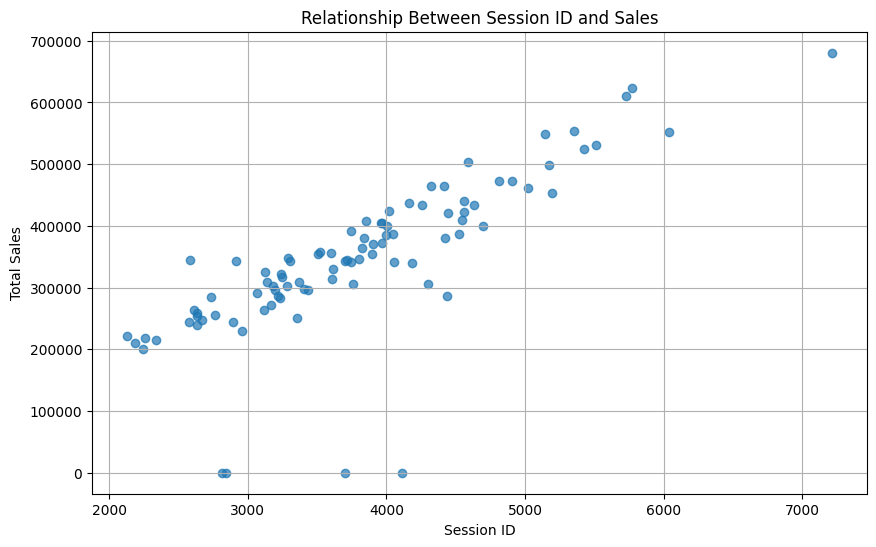

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_grouped["sessions"], df_grouped["total_sales"], alpha = 0.7)
plt.title("Relationship Between Session ID and Sales")
plt.xlabel("Session ID")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

**Отже:**

Аналогічно на графіку видно лінійний сильний позитивний звязок між кількістю сесій та сумою продажів. Зі зростанням значення sessions зростає і показник Total Sales. Внизу графіка присутні викиди, нульові значення, що свідчить або про те, що при такій кількості сесій купівлі не відбуваються, або повязано з помилками запису, технічних збоях в сесіях

### 7.2. Чи корелюють між собою продажі на різних континентах? Взяти топ-3 континенти. Проаналізувати статистичну значущість взаємозв’язків.


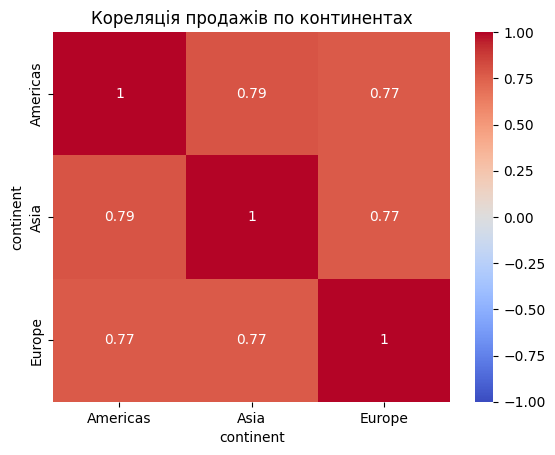

In [ ]:
continent_sales = df.groupby(["continent", "date"])["product_price"].sum().reset_index()
top_3_continents = continent_sales.groupby("continent")["product_price"].sum().nlargest(3).index
filtered_continent_sales = continent_sales[continent_sales["continent"].isin(top_3_continents)]
pivot_table_continent = pd.pivot_table(filtered_continent_sales, values="product_price", index="date", columns="continent", aggfunc="sum")

# побудова теплової карти для кореляції
correlation = pivot_table_continent.corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція продажів по континентах")
plt.show()

In [ ]:
continent_1_sales = pivot_table_continent[top_3_continents[0]].dropna()
continent_2_sales = pivot_table_continent[top_3_continents[1]].dropna()
continent_3_sales = pivot_table_continent[top_3_continents[2]].dropna()

coef_1_2, p_value_1_2 = pearsonr(continent_1_sales, continent_2_sales)
coef_1_3, p_value_1_3 = pearsonr(continent_1_sales, continent_3_sales)
coef_2_3, p_value_2_3 = pearsonr(continent_2_sales, continent_3_sales)
print(f"p-значення: {p_value_1_2} між {top_3_continents[0]} та {top_3_continents[1]}")
print(f"p-значення: {p_value_1_3} між {top_3_continents[0]} та {top_3_continents[2]}")
print(f"p-значення: {p_value_2_3} між {top_3_continents[1]} та {top_3_continents[2]}")

p-значення: 5.409189396197475e-21 між Americas та Asia
p-значення: 2.6714492240629956e-19 між Americas та Europe
p-значення: 3.8649460090531196e-19 між Asia та Europe


**Отже:**


З теплової карти на основі кореляції Пірсона робимо висновок що існує сильний лінійний позитивний звязок між всіма ринками, значення в межах 0.77-0.79 Найсильніший зв'язок спостерігається між Americas та Asia (0.79)

p-value для кожної з комбінацій континентів нескінечено мале і є статистично значущим, отже результат не є випадковий і кореляція сильна.

Такі результати можуть свідчити те, що продажі на всіх топ-3 континентах змінюються схожим чином. Це може говорити про те, що бізнес залежить від глобальних чинників, а не від локалльних подій. Так, вихід нового продукту, акції або сезонність впливають на всі ринки майже однаково.

In [ ]:
coef_1_2, p_value_1_2 = spearmanr(continent_1_sales, continent_2_sales)
coef_1_3, p_value_1_3 = spearmanr(continent_1_sales, continent_3_sales)
coef_2_3, p_value_2_3 = spearmanr(continent_2_sales, continent_3_sales)
print(f"t-stat: {coef_1_2} між {top_3_continents[0]} та {top_3_continents[1]}")
print(f"p-значення: {p_value_1_2} між {top_3_continents[0]} та {top_3_continents[1]}")
print(f"t-stat: {coef_1_3} між {top_3_continents[0]} та {top_3_continents[2]}")
print(f"p-значення: {p_value_1_3} між {top_3_continents[0]} та {top_3_continents[2]}")
print(f"t-stat: {coef_2_3} між {top_3_continents[1]} та {top_3_continents[2]}")
print(f"p-значення: {p_value_2_3} між {top_3_continents[1]} та {top_3_continents[2]}")

t-stat: 0.7099016615801969 між Americas та Asia
p-значення: 2.3233796296203977e-15 між Americas та Asia
t-stat: 0.6725700545639509 між Americas та Europe
p-значення: 2.1035588726455927e-13 між Americas та Europe
t-stat: 0.6571102685039614 між Asia та Europe
p-значення: 1.1290947217450973e-12 між Asia та Europe


Додатково було здійснено тест Спірмена

**Отже:**

Існує сильний-середній позитивний звязок між всіма ринками, значення в межах 0.67-0.71. Найсильніший зв'язок все ще спостерігається між Americas та Asia (0.71) - сильний звязок. Інші звязки є середньою кореляцією: 0.6725700545639509 між Americas та Europe, 0.6571102685039614 між Asia та Europe

p-value для кожної з комбінацій континентів нескінечено мале і є статистично значущим, отже результат не є випадковий.

Високі значення Пірсона говорять про те, що звязки є лінійними, а високі значення Спірмена говорять про монотонність даних, рух в одному напрямку. Значення Спірмена (0.67-0.71) та Пірсона (0.77-0.79) дещо відрізняються, однак звязок все ще близький до сильного і ця різниця несуттєва. До того ж, тест Спірмена менш чутливий до викидів і нижче значення цього тесту може бути спричиненим наявністю аномалій.

### 7.3. Чи корелюють між собою продажі за різними каналами трафіку? Проаналізувати статистичну значущість взаємозв’язків.


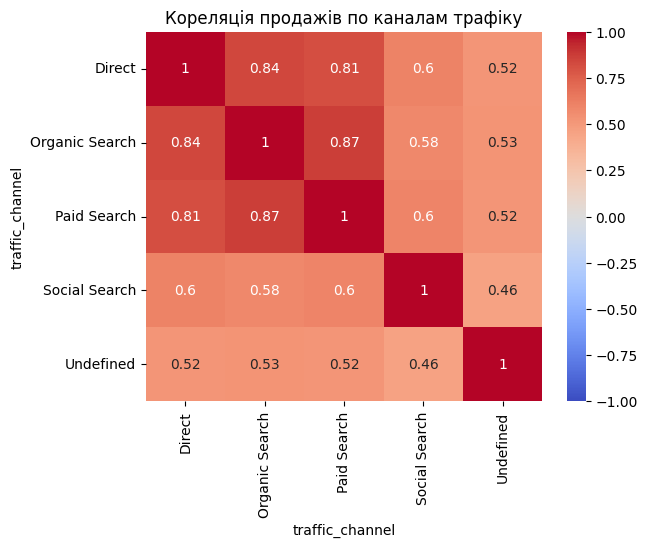

In [ ]:
df_pivot = df.pivot_table(index="date", columns = "traffic_channel", values="product_price", aggfunc="sum").reset_index().drop(columns = ["date"])
correlation = df_pivot.corr()
sns.heatmap(correlation, annot = True, vmin = -1, vmax = 1, cmap = "coolwarm")
plt.title("Кореляція продажів по каналам трафіку")
plt.show()

In [ ]:
channels_sales = [
    df_pivot.iloc[:, 0].dropna(),
    df_pivot.iloc[:, 1].dropna(),
    df_pivot.iloc[:, 2].dropna(),
    df_pivot.iloc[:, 3].dropna(),
    df_pivot.iloc[:, 4].dropna()
]

channels_names = df_pivot.columns


for (i, j) in combinations(range(len(channels_names)), 2):
  coef, p_value = pearsonr(channels_sales[i], channels_sales[j])
  print(f"p_value між {channels_names[i]} та {channels_names[j]} становить {p_value}")

p_value між Direct та Organic Search становить 2.1904196603645366e-25
p_value між Direct та Paid Search становить 5.896434878977516e-23
p_value між Direct та Social Search становить 1.831889246946262e-10
p_value між Direct та Undefined становить 1.2754357002002653e-07
p_value між Organic Search та Paid Search становить 2.1420029219324783e-29
p_value між Organic Search та Social Search становить 1.0661924301883206e-09
p_value між Organic Search та Undefined становить 7.228214166055068e-08
p_value між Paid Search та Social Search становить 3.5322844619049755e-10
p_value між Paid Search та Undefined становить 9.509608507736478e-08
p_value між Social Search та Undefined становить 5.161927926222991e-06


**Отже:**


З теплової карти робимо висновок що існує сильний/середній лінійний позитивний звязок між всіма трафіками. Зростання одного каналу практично завжди супроводжується зростанням інших. Маємо наступні результати:

*  Найсильніші звязки мають Paid Search і Organic Serch(0.87), що є логічним, оскільки якщо продукт став популярним, люди починають масово гуглити його, вони бачать на екрані і рекламу, і органіку, так, кількість кліків зростає в обох каналах.
*  Ще сильний звязок мають Organic Search і Direct(0.84), теж логічно, оскільки користувачі знаходять сайт через Google (Organic), запам'ятовують бренд, а наступного разу вводять URL напряму (Direct).
*  Також сильний звязок мають Paid Search і Direct(0.81). Користувач бачить платне оголошення, запам'ятовує компанію та пізніше вводить її вручну (Direct).
*  Для Social Serach та Undefined маємо нижчи показники з іншими трафіками, Social Search та Undefined розвиваються за власними траєкторіями й мало залежать від інших каналів. Для Social Seacrh (0.46 - 0.6), трафік із соцмереж залежить від вірусного контенту або трендів, а не від системного пошукового попиту. Для Underfined (що складається з технічних помилок аналітики) має кореляцію 0.46-0.53, цей трафік не має єдиної природи, його коливання є випадковими.
*  p-value для кожної з комбінацій нескінечено мале і є статистично значущим, отже результат не є випадковий

In [ ]:
for (i, j) in combinations(range(len(channels_names)), 2):
  coef, p_value = spearmanr(channels_sales[i], channels_sales[j])
  print(f"t-stat між {channels_names[i]} та {channels_names[j]} = {coef}")
  print(f"p_value між {channels_names[i]} та {channels_names[j]} = {p_value}\n")

t-stat між Direct та Organic Search = 0.7796633681679461
p_value між Direct та Organic Search = 5.405253983075643e-20

t-stat між Direct та Paid Search = 0.729368969450353
p_value між Direct та Paid Search = 1.65402161751709e-16

t-stat між Direct та Social Search = 0.46934245815222425
p_value між Direct та Social Search = 2.365556386712662e-06

t-stat між Direct та Undefined = 0.556922223249792
p_value між Direct та Undefined = 8.156166744014837e-09

t-stat між Organic Search та Paid Search = 0.7933814235950555
p_value між Organic Search та Paid Search = 4.16183654939949e-21

t-stat між Organic Search та Social Search = 0.4615432041678228
p_value між Organic Search та Social Search = 3.6452140656893687e-06

t-stat між Organic Search та Undefined = 0.5246770862233732
p_value між Organic Search та Undefined = 7.935217742014988e-08

t-stat між Paid Search та Social Search = 0.492724806560005
p_value між Paid Search та Social Search = 6.0588880791877e-07

t-stat між Paid Search та Undefin


Додатково було проведено тест Спірмена на монотонність, p-value аналогічно нескінченно мале, отже результати є статистично значущими. Значення кореляції Спірмена менше від кореляції Пірсонав середньому на 0.1-0.15, що означає що зв'язок між каналами трафіку є лінійним, але присутні аномалії


### 7.4. Чи корелюють між собою продажі за топ-5 категоріями товарів? Проаналізувати статистичну значущість взаємозв’язків.

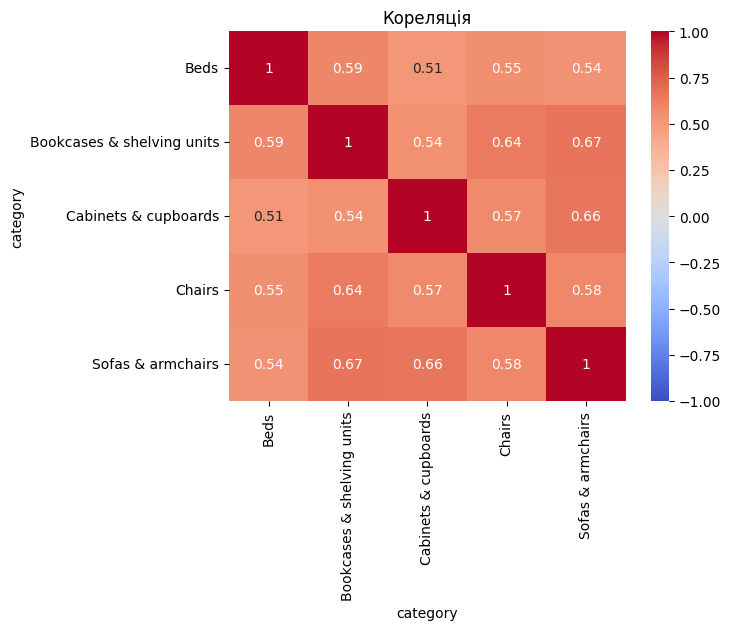


p_value між Beds та Bookcases & shelving units становить 1.1549982399950595e-09
p_value між Beds та Cabinets & cupboards становить 2.9109296191322004e-07
p_value між Beds та Chairs становить 2.079182865492252e-08
p_value між Beds та Sofas & armchairs становить 7.687332925177328e-08
p_value між Bookcases & shelving units та Cabinets & cupboards становить 5.8672250979394714e-08
p_value між Bookcases & shelving units та Chairs становить 2.5045503773672356e-11
p_value між Bookcases & shelving units та Sofas & armchairs становить 1.4069719486806666e-12
p_value між Cabinets & cupboards та Chairs становить 5.46590349515409e-09
p_value між Cabinets & cupboards та Sofas & armchairs становить 3.4150555904339523e-12
p_value між Chairs та Sofas & armchairs становить 3.6388330532540413e-09


In [ ]:
df_grouped = df.groupby(["date", "category"])["product_price"].sum().reset_index()
top_5_cat = df_grouped.groupby("category")["product_price"].sum().nlargest(5).index
filtered_cat_sales = df_grouped[df_grouped["category"].isin(top_5_cat)]
df_pivot = pd.pivot_table(filtered_cat_sales, index = "date", columns = "category", values = "product_price", aggfunc = "sum").reset_index().drop(columns = ["date"])
correlation = df_pivot.corr()
sns.heatmap(correlation, annot = True, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Кореляція")
plt.show()

cat_sales = [
    df_pivot.iloc[:, 0],
    df_pivot.iloc[:, 1],
    df_pivot.iloc[:, 2],
    df_pivot.iloc[:, 3],
    df_pivot.iloc[:, 4]
]

cat_names = df_pivot.columns
print()
for (i, j) in combinations(range(len(cat_sales)), 2):
    coef, p_value = pearsonr(cat_sales[i], cat_sales[j])
    print(f"p_value між {cat_names[i]} та {cat_names[j]} становить {p_value}")

**Отже:**


З теплової карти робимо висновок що існує помірний лінійний позитивний звязок між топ-5 категоріями. Маємо наступні результати:
*  Beds (Ліжка) мають найвищий зв'язок із стелажами (Bookcases&shelving units) -0.59,  найнижчі з Cabinets&cupboards(комоди/шафки)  - 0.51.
*  Bookcases & shelving units (Стелажі/книжкові полиці) з диванами найвищі(Sofas&armchairs) - 0.67, а найнижчі з cabinets & cupboards (комоди/шафки) - 0.54.
*  Cabinets & cupboards (комоди/шафки) показують сильніший зв'язок із диванами та кріслами (Sofas&armchairs) -0.66, а найменше з ліжка -0.51.
*  Chairs (стільці) показують сильніший зв'язок із Bookcases & shelving units (Стелажі/книжкові полиці) - 0.64, найменше Beds(ліжка) - 0.55.
*  Sofas&armchairs показують сильніший зв'язок із Bookcases & shelving units (Стелажі/книжкові полиці) - 0.67, найменше Beds(ліжка) - 0.54.
*  p-value для кожної з комбінацій нескінечено мале і є статистично значущим, отже результат не є випадковий

In [ ]:
for (i, j) in combinations(range(len(cat_sales)), 2):
    coef, p_value = spearmanr(cat_sales[i], cat_sales[j])
    print(f"t-stat між {cat_names[i]} та {cat_names[j]} = {coef}")
    print(f"p_value між {cat_names[i]} та {cat_names[j]} становить {p_value}\n")

t-stat між Beds та Bookcases & shelving units = 0.5427424183720194
p_value між Beds та Bookcases & shelving units становить 4.690831718453576e-08

t-stat між Beds та Cabinets & cupboards = 0.4403684266140679
p_value між Beds та Cabinets & cupboards становить 1.7587830397743514e-05

t-stat між Beds та Chairs = 0.5349406502060513
p_value між Beds та Chairs становить 7.913415552119658e-08

t-stat між Beds та Sofas & armchairs = 0.521714627875031
p_value між Beds та Sofas & armchairs становить 1.864367723360297e-07

t-stat між Bookcases & shelving units та Cabinets & cupboards = 0.5287062801592055
p_value між Bookcases & shelving units та Cabinets & cupboards становить 1.1906129581027331e-07

t-stat між Bookcases & shelving units та Chairs = 0.6367510830897116
p_value між Bookcases & shelving units та Chairs становить 2.5854375788053062e-11

t-stat між Bookcases & shelving units та Sofas & armchairs = 0.6256031841076398
p_value між Bookcases & shelving units та Sofas & armchairs становить 


Додатково було проведено тест Спірмена на монотонність, p-value аналогічно близько до 0 і < 0.05, отже результати є статистично значущими і невипадковими. Значення кореляції Спірмена менше від кореляції Пірсона в середньому на 0.05-0.1, що означає що зв'язок між каналами трафіку є лінійним і присутні аномалії


### 7.5. Чи корелюють між собою продажі за топ-4 операційних систем? Проаналізувати статистичну значущість взаємозв’язків.

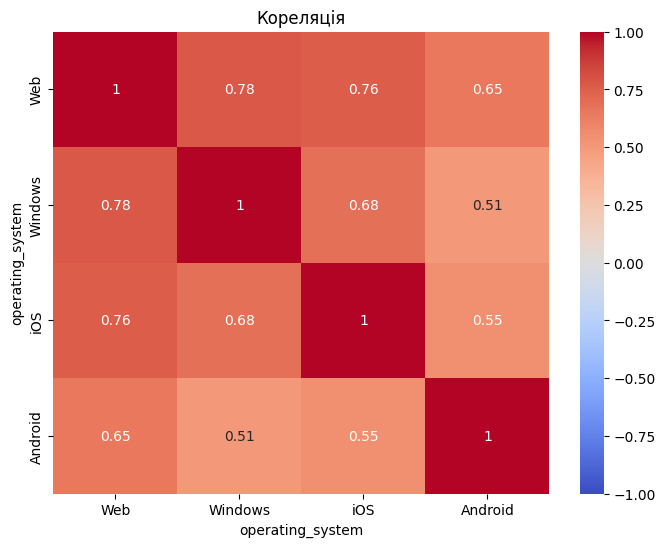


p-значення: 6.832009086065275e-20 між Web та Windows
p-значення: 9.434485109229272e-19 між Web та iOS
p-значення: 2.133162330888717e-12 між Web та Android
p-значення: 6.470614304940276e-14 між Windows та iOS
p-значення: 2.698407306548889e-07 між Windows та Android
p-значення: 1.084344031045914e-08 між iOS та Android


In [ ]:
df_os_sales = df.groupby(["date", "operating_system"])["product_price"].sum().unstack(fill_value=0)
top_4_os = df_os_sales.sum().nlargest(4).index
filtered_cat_sales = df_os_sales[top_4_os]
correlation = filtered_cat_sales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція")
plt.show()

print()

for (i, j) in combinations(filtered_cat_sales.columns, 2):
    sales_os_1 = filtered_cat_sales[i]
    sales_os_2 = filtered_cat_sales[j]
    coef, p_value = pearsonr(sales_os_1, sales_os_2)
    print(f"p-значення: {p_value} між {i} та {j}")


**Отже:**


З теплової карти робимо висновок що існує середньо-помірний лінійний позитивний звязок між топ-4 операційними ситемами. Усі коефіцієнти знаходяться в діапазоні від 0.51 до 0.78. Це означає, що коли ростуть продажі на одній платформі, вони синхронно зростають і на інших.

Маємо наступні результати:
*  Найсильніший зв'язок (Web та Windows = 0.78), продажі через веб-версію та десктопну Windows змінюються практично однаково.
*  Високий зв'язок мобільних платформ із Web (Web та iOS = 0.76, Web і Android = 0.65).
*  Найслабші зв'язоки Windows і Android = 0.51, Android та iOS = 0.55. Продажі на Android менше залежать від коливань продажів на Windows та iOS, ніж у WEb.
*  p-value для кожної з комбінацій нескінечено мале і є статистично значущим, отже результат не є випадковий

In [ ]:
for (i, j) in combinations(filtered_cat_sales.columns, 2):
    sales_os_1 = filtered_cat_sales[i]
    sales_os_2 = filtered_cat_sales[j]
    coef, p_value = spearmanr(sales_os_1, sales_os_2)
    print(f"t-stat: {coef} між {i} та {j}")
    print(f"p-значення: {p_value} між {i} та {j}\n")

t-stat: 0.7400659699744137 між Web та Windows
p-значення: 3.506096894450045e-17 між Web та Windows

t-stat: 0.7268565615462871 між Web та iOS
p-значення: 2.3559240217092368e-16 між Web та iOS

t-stat: 0.6160177564043282 між Web та Android
p-значення: 6.319554381035067e-11 між Web та Android

t-stat: 0.6280403218348286 між Windows та iOS
p-значення: 2.0696513985526276e-11 між Windows та iOS

t-stat: 0.43461574031258676 між Windows та Android
p-значення: 1.498714105049055e-05 між Windows та Android

t-stat: 0.5279447578532015 між iOS та Android
p-значення: 6.369024785717121e-08 між iOS та Android




Для тесту Спірмена p-value аналогічно близько до 0 і < 0.05, отже результати є статистично значущими і невипадковими. Аналогічно як і в попередніх випадках, значення кореляції менше від кореляції Пірсона в середньому на 0.05-0.1, що означає що зв'язок між каналами трафіку є лінійним і присутні аномалії


## 8. Статистичний аналіз відмінностей між групами.

### 8.1. Проаналізувати продажі за кожну дату зареєстрованих та незареєстрованих користувачів. Створити відповідні вибірки, проаналізувати розподіли даних в обох вибірках. Підібрати відповідний статистичний тест для порівняння вибірок.

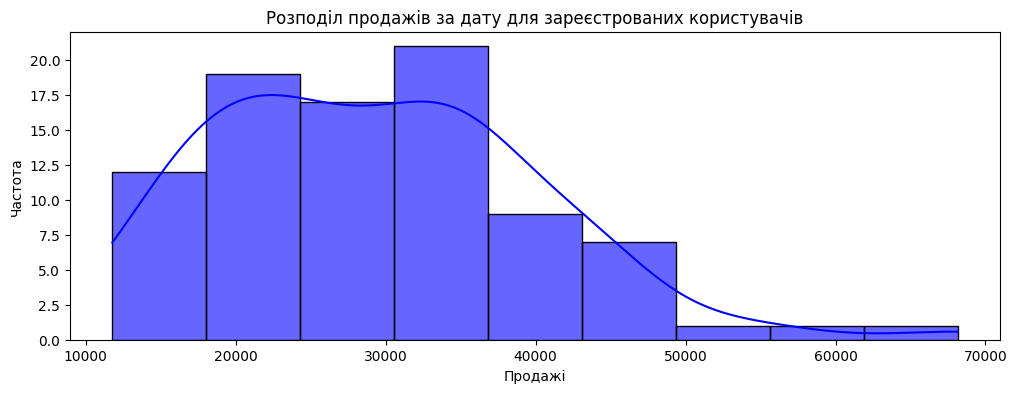

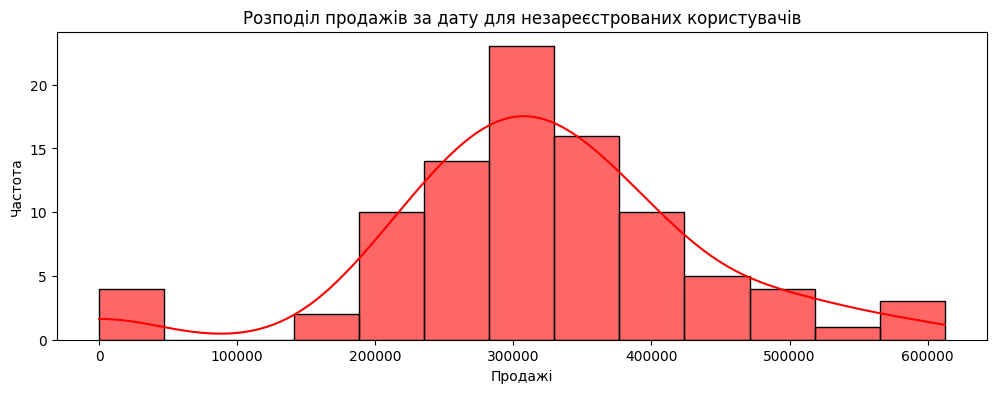

In [ ]:
registered = df[df["is_registered"] == True]
unregistered = df[df["is_registered"] == False]

reg_grouped = registered.groupby("date")["product_price"].sum().reset_index()
unreg_grouped = unregistered.groupby("date")["product_price"].sum().reset_index()

plt.figure(figsize=(12, 4))
sns.histplot(reg_grouped["product_price"], kde=True, color="blue", alpha=0.6)
plt.title("Розподіл продажів за дату для зареєстрованих користувачів")
plt.xlabel("Продажі")
plt.ylabel("Частота")
plt.figure(figsize=(12, 4))
sns.histplot(unreg_grouped["product_price"], kde=True, color="red", alpha=0.6)
plt.title("Розподіл продажів за дату для незареєстрованих користувачів")
plt.xlabel("Продажі")
plt.ylabel("Частота")

plt.show()

* _Для зареєстрованих користувачів_: розподіл вибірки не схожий на нормальний, а більше на right-screwed розподіл
* _Для незареєстрованих користувачів_: розподіл вибірки більше схожий на нормальний, однак у лівій частині графіка є сплеск ближче до 0, також є невеликий підйом з правої сторони

In [ ]:
stat_reg, p_reg = normaltest(reg_grouped["product_price"])
stat_unreg, p_unreg = normaltest(unreg_grouped["product_price"])

print(f"Нормальність для зареєстрованих користувачів: {p_reg}")
print(f"Нормальність для незареєстрованих користувачів: {p_unreg}")

if p_reg > 0.05 and p_unreg > 0.05:
  print("\nДані нормально розподілені")
  coef, p_value = ttest_ind(reg_grouped["product_price"], unreg_grouped["product_price"])
  print(f"t-тест: stat = {coef}, p-value = {p_value}")
else:
  print("\nДані ненормально розподілені")
  coef, p_value = mannwhitneyu(reg_grouped["product_price"], unreg_grouped["product_price"])
  print(f"Тест Манна-Уітні: stat = {coef}, p-value = {p_value}")

Нормальність для зареєстрованих користувачів: 0.010929121653065912
Нормальність для незареєстрованих користувачів: 0.026362411185738954

Дані ненормально розподілені
Тест Манна-Уітні: stat = 352.0, p-value = 3.8805185465235906e-26


Оскільки вибірка велика, для дослідження нормальності розподілу було використано normaltest (Пірсона-д'Агостино) з scipy.stats.


Оскільки вибірки лише 2 і вони обидві кількісні, то їх для порівняння можна обрати t-тест та тест Манна-Уітні:
* Якщо дані нормально розподілені (тобто p-value > 0.05 для 2 вибірок), використовуємо ttest_ind з scipy.stats
* Якщо дані ненормально розподілені (тобто p-value < 0.05 для 2 вибірок), використовуємо mannwhitneyu з scipy.stats

**В результаті:** дані ненормально розподілені, тому вибір припав на тест Манна-Уітні. Оскільки p-value нескінченно мале, маємо підстави, щоб відкинути нульову гіпотезу і стверджувати, що різниця між вибірками не є випадковою і ця різниця є статистично значуща.

### 8.2. Проаналізувати кількість сесій за різними каналами трафіку. Підібрати відповідний тест.


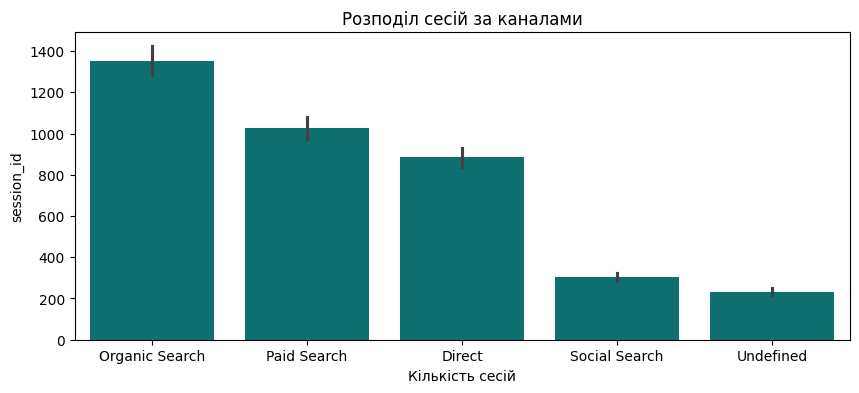

In [ ]:
import scipy.stats as stats

traffic_data = df.groupby(["date", "traffic_channel"])["session_id"].count().sort_values(ascending = False).reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(x = "traffic_channel", y = "session_id", data = traffic_data, color="teal")
plt.title(f"Розподіл сесій за каналами")
plt.xlabel("Канал")
plt.xlabel("Кількість сесій")
plt.show()


Найбільше сесій припадає на _Organic Search_, далі іде _Paid Search, Direct, Social Search_, найменше - на _Underfined_

Перевірка на нормальність розподілу в каналах:



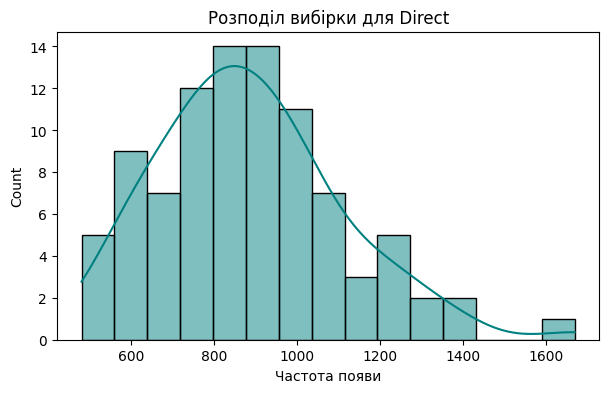


Direct - розподіл ненормальний: p_value = 0.007853358264896217



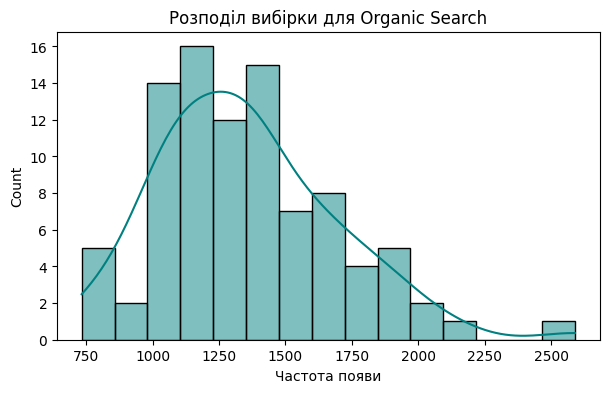


Organic Search - розподіл ненормальний: p_value = 0.0031046084804515037



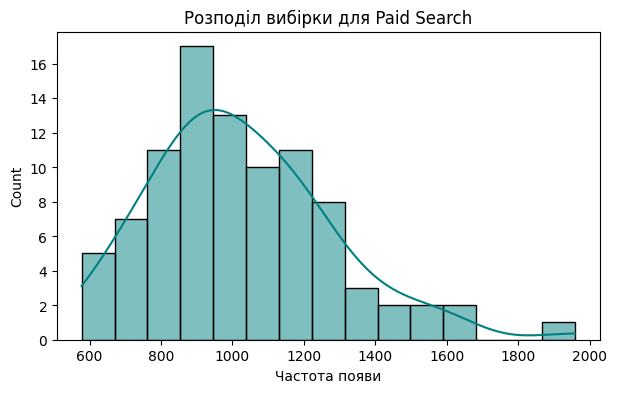


Paid Search - розподіл ненормальний: p_value = 0.0016504167955096551



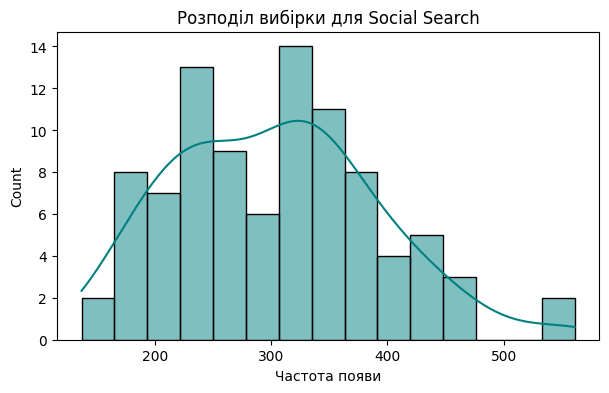


Social Search - розподіл нормальний: p_value = 0.21439918696878835



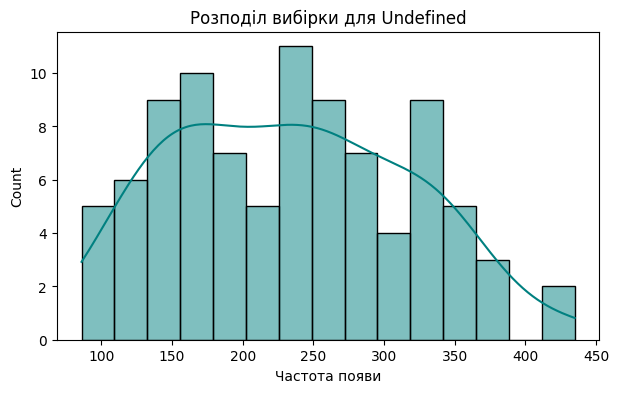


Undefined - розподіл ненормальний: p_value = 0.0402046864129123



In [ ]:
traffic_data = df.groupby(["date", "traffic_channel"])["session_id"].count().unstack(fill_value=0)

print("Перевірка на нормальність розподілу в каналах:\n")
all_normality = True
alpha = 0.05

for channel in traffic_data.columns:
  data_points = traffic_data[channel].values
  _, p_value = normaltest(data_points)

  plt.figure(figsize=(7, 4))
  sns.histplot(data_points, kde=True, color="teal", bins=15)
  plt.title(f"Розподіл вибірки для {channel}")
  plt.xlabel("Кількість сесій")
  plt.xlabel("Частота появи")
  plt.show()


  if p_value < alpha:
    print(f"\n{channel} - розподіл ненормальний: p_value = {p_value}\n")
    all_normality = False
  else:
    print(f"\n{channel} - розподіл нормальний: p_value = {p_value}\n")

**Нормальність вибірок візуально:**
* Розподіл Direct, Paid Search та Organic Search по графіку більше схожі на right-skewed розподіл, з занадто довгим хвостом з правої сторони.
* Розподіл Social Search більше з поміж усіх каналів схожий на нормальний. Основна маса даних зосереджена в центрі, хоча є певні пікові значення в цих межах, а в лівий та правий боки частота появи значень спадає. Візуально є сумніви щодо нормальності, тому краще провести тест на нормальність даних.
* Розподіл Underfined теж дещо схожий на нормальний, але з лівої сторони більша кількість сесій ніж з правої сторони.


**Нормальність вибірок по тесту:**

Оскільки вибірка велика, для дослідження нормальності розподілу було використано normaltest (Пірсона-д'Агостино) з scipy.stats. Згідно тесту, нормальний розподіл має тільки Social Search канал, оскільки p = 0.21 > 0.05, отже не відкидаємо нульову гіпотезу про нормальність.


In [ ]:
channel_groups = [traffic_data[channel].values for channel in traffic_data.columns]

if all_normality:
  print("Дані нормально рохподілені: Однофакторний дисперсійний аналіз\n")
  stat, p_value = stats.f_oneway(*channel_groups)
  print(f"Statistic = {stat:.4f}")
  print(f"p-value = {p_value:.4e}")
else:
  print("Дані ненормально розподілені: тест Крускала-Уоліса\n")
  stat, p_value = stats.kruskal(*channel_groups)
  print(f"Statistic = {stat:.4f}")
  print(f"p-value = {p_value:.4e}")


if p_value < alpha:
    print("\nКількість щоденних сесій між різними каналами трафіку суттєво відрізняється")
else:
    print("\nНемає підстав стверджувати, що канали приносять різну кількість сесій")

Дані ненормально розподілені: тест Крускала-Уоліса

Statistic = 368.9806
p-value = 1.3970e-78

Кількість щоденних сесій між різними каналами трафіку суттєво відрізняється


Оскільки вибірок 5, то їх для порівняння  було виіршено обрати або ANOVA або тест Крускала-Уоліса:
* Якщо дані нормально розподілені (тобто p-value > 0.05 для всіх вибірок), використовуємо ANOVA (stats.f_oneway)
* Якщо дані ненормально розподілені (тобто p-value < 0.05 для всіх вибірок), використовуємо тест Крускала-Уоліса (stats.kruskal)

**В результаті:** дані ненормально розподілені, тому вибір припав на тест Краскала-Уоліса. Оскільки p-value нескінченно мале, маємо підстави, щоб відкинути нульову гіпотезу і стверджувати, що різниця між вибірками суттєво відрізняється.

### 8.3. Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці? Підібрати відповідний тест.

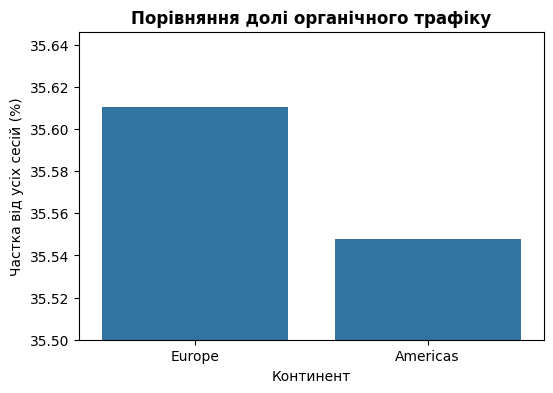

In [ ]:
geo_df = df[df["continent"].isin(["Europe", "Americas"])].copy()

total_e = geo_df[geo_df["continent"] == "Europe"]["session_id"].nunique()
total_a = geo_df[geo_df["continent"] == "Americas"]["session_id"].nunique()

organic_e = geo_df[(geo_df["continent"] == "Europe")&(geo_df["traffic_channel"] == "Organic Search")]["session_id"].nunique()
organic_a = geo_df[(geo_df["continent"] == "Americas")&(geo_df["traffic_channel"] == "Organic Search")]["session_id"].nunique()

part_e = organic_e/total_e
part_a = organic_a/total_a

plt.figure(figsize = (6, 4))
plt_data = pd.DataFrame({
    "Континент": ["Europe", "Americas"],
    "Частка органічного пошуку": [part_e * 100, part_a * 100]
})

sns.barplot(data=plt_data, x="Континент", y="Частка органічного пошуку")
plt.title("Порівняння долі органічного трафіку", fontsize=12, fontweight="bold")
plt.ylabel("Частка від усіх сесій (%)")
plt.ylim(35.5, max(part_e, part_a) * 100.1)
plt.show()

По графіку різниця між долями органічного трафіку в Європі та Америці відрізняється на близько 0.05%, що є невеликою різницею. Додатково проведемо тест, щоб переконатися в цьому.

In [ ]:
z_stat, p_value = sm.stats.proportions_ztest([organic_e, organic_a], [total_e, total_a])

print(f"Результати Z-тесту:")
print(f"Z-statistic = {z_stat:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nДоля органічного трафіку в Європі ({part_e:.2%}) та Америці ({part_a:.2%}) суттєво відрізняється.")
else:
    print("\nРізниця в частках органічного трафіку між континентами є випадковою.")

Результати Z-тесту:
Z-statistic = 0.2895
p-value = 0.7722

Різниця в частках органічного трафіку між континентами є випадковою.


**Отже:**

У якості тест використано z-тест пропорцій (proportions_ztest з бібліотеки statsmodels.api), що порівнює різницю між частками в групах. Оскільки p-value = 0.722 > 0.05, немає підстав відкидати нульову гіпотезу і різниця в частках є випадковою.


## 9. Створення аналітичний дашборд у Tableau Public

Посилання на Tableau Public: https://public.tableau.com/app/profile/olena.patsan/viz/portfolio_17810440430500/DynamicsDashboard

1 сторінка дашборду:

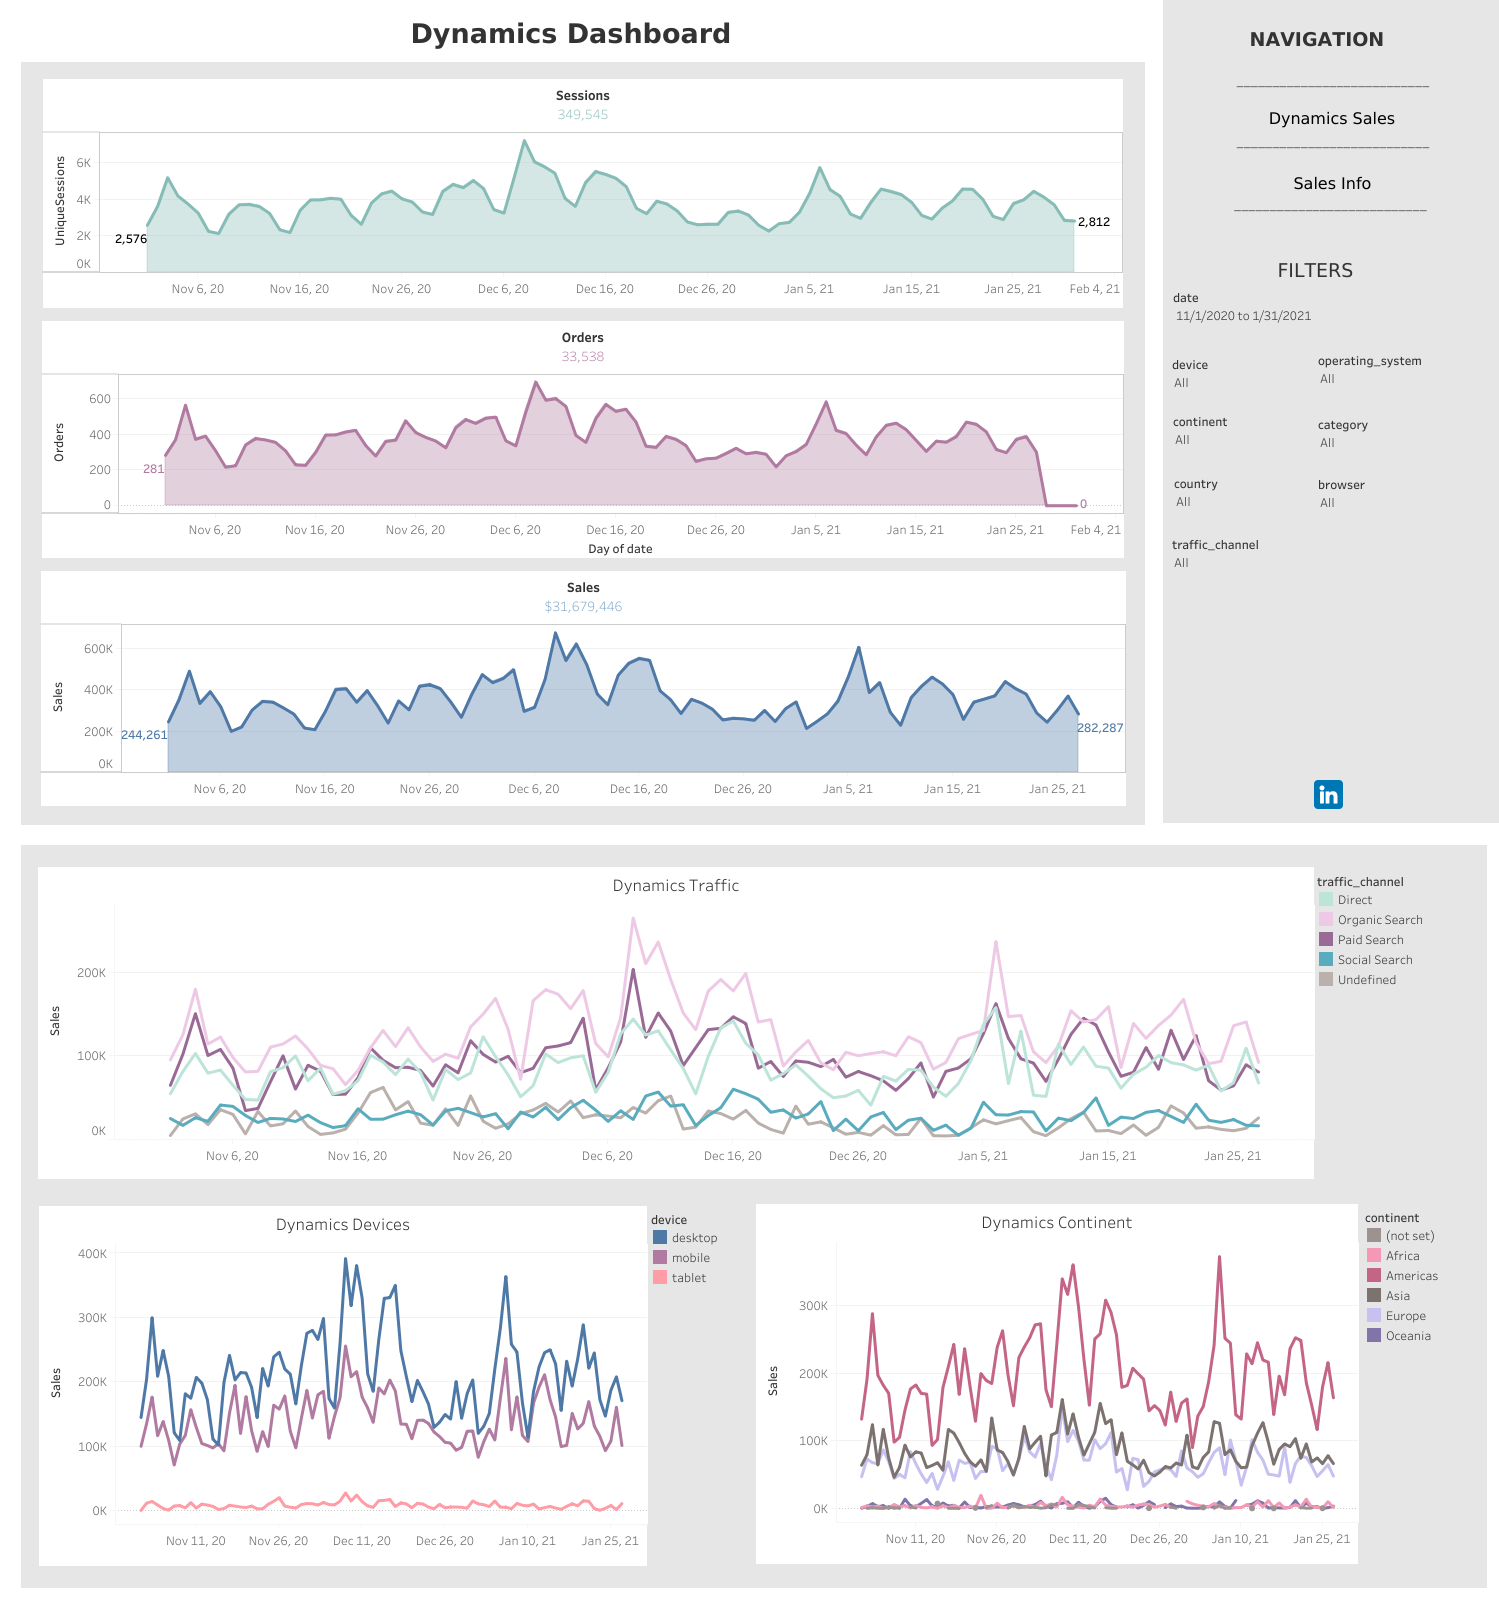

2 сторінка дашборду:

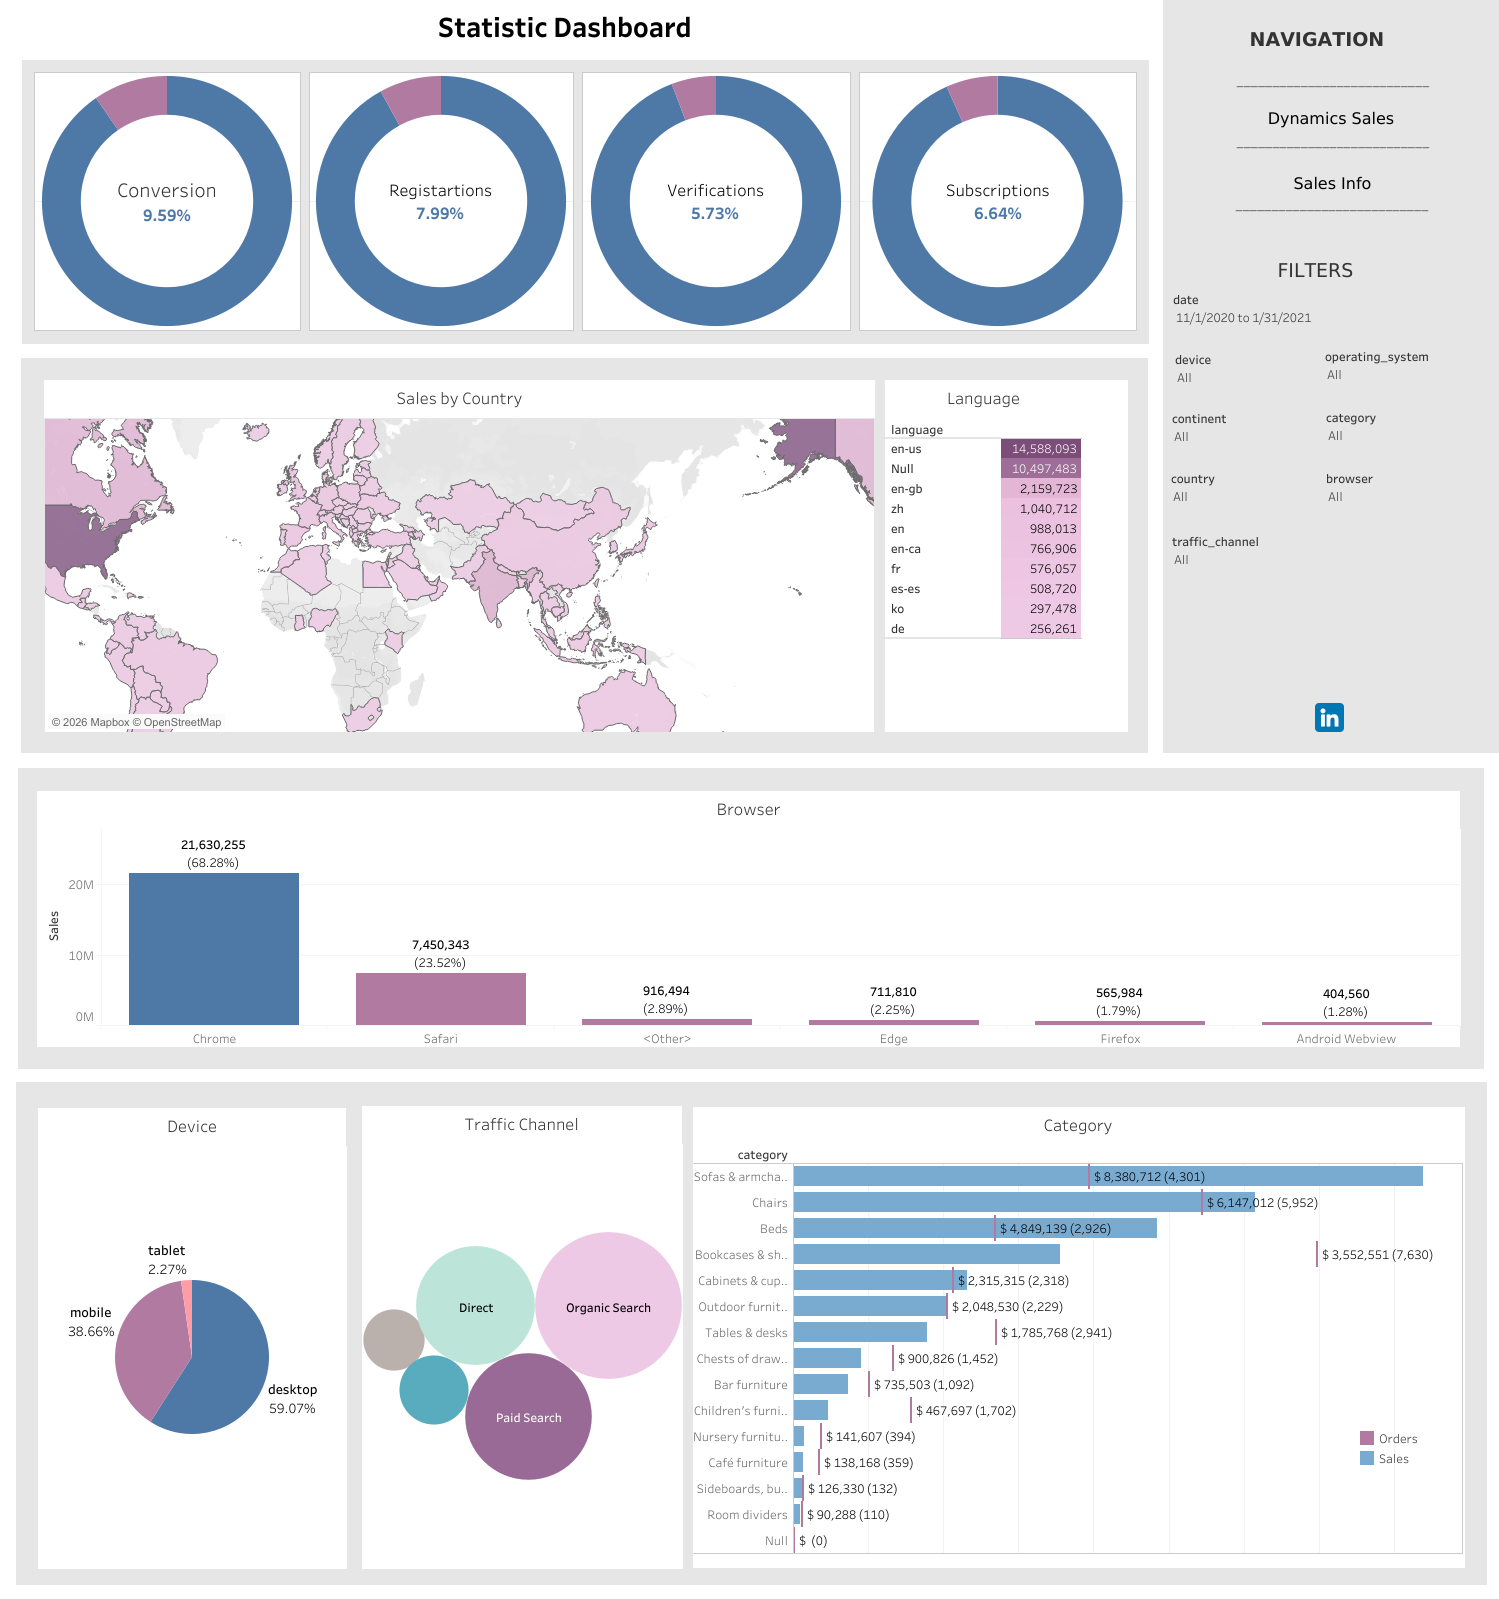